In [260]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

#### Correzzioni degli offset.


Nella correzione Lente 1, offset_LENTE1_A e offset_LENTE1_B rappresentano rispettivamente la distanza tra l'asse del carrellino e V e la distanza tra l asse del carrellino e V'.

VV_LENTE1 è la distanza VV' data come specifica della lente (c'è una piccola incongruenza dato che la somma di offset_A e offset_B non è uguale a VV).

In offset_LENTE1_q e offset_LENTE1_p il primo e secondo termine se sommati definiscono l'offset dell'asse della lente (che non combacia con l'asse del carrellino) mentre VV/3 rappresenta l'offset dovuto alla distanza tra asse della lente e i piani principali.

In offset_LENTE2 avremmo dovuto applicare lo stesso concetto ma, non avendo a disposizione una misura paragonabile a offset_A e offset_B ma per la lente 2, si preferisce approssimare il centro della lente come coincidente al centro del carrellino.

In [261]:
tecnica = 0.3 * 1/np.sqrt(12)

In [262]:
#Correzione distanza oggetto:
SBARRETTA = [82.0, 0.5/np.sqrt(24)]
SCHERMO = [75.0, tecnica]
CARRELLINO = [25.4, tecnica]
OGGETTO = [35.0, 0.5/np.sqrt(24)]
offset_OGGETTO = [SBARRETTA[0] + SCHERMO[0]/2 - CARRELLINO[0]/2 - OGGETTO[0],
                  f.propaga_incertezza(
                        "x + y - z/2 - w",
                        ["x","y","z","w"],
                        [SBARRETTA[0],SCHERMO[0],CARRELLINO[0],OGGETTO[0]],
                        [SBARRETTA[1],SCHERMO[1],CARRELLINO[1],OGGETTO[1]],
                        ritorno=True
                  )[0]
                  ]

print(f"offset_OGGETTO = {gf.formatta_errore(offset_OGGETTO[0],offset_OGGETTO[1],txt=True)}")

#Correzione CCD:
PIANO_IMMAGINE = [9.0, tecnica]
CCD = [6.0, tecnica]
offset_CCD = [CARRELLINO[0]/2 + PIANO_IMMAGINE[0] - CCD[0],
                f.propaga_incertezza(
                        "x/2 + y - z",
                        ["x","y","z"],
                        [CARRELLINO[0],PIANO_IMMAGINE[0],CCD[0]],
                        [CARRELLINO[1],PIANO_IMMAGINE[1],CCD[1]],
                        ritorno=True
                )[0]
                ]

print(f"offset_CCD = {gf.formatta_errore(offset_CCD[0],offset_CCD[1],txt=True)}")

# _________________________________________________________________________________________________

#Correzione Lente 1:
print("\nLente 1")
PA = [69.0, 0.5/np.sqrt(24)] # Punto a destra della base del carrellino del portalente
PB = [77.0, 0.5/np.sqrt(24)] # Uguale a PA, ma con il portalente ruotato
LENTE1 = [170.5, 0.5/np.sqrt(24)] # Punto a sinistra della base del carrellino dello schermo
offset_LENTE1_A = [CARRELLINO[0] + LENTE1[0] - PA[0] - SCHERMO[0]/2 - SBARRETTA[0],
                   f.propaga_incertezza(
                       "x + y - z - w/2 - q",
                       ["x","y","z","w","q"],
                       [CARRELLINO[0],LENTE1[0],PA[0],SCHERMO[0],SBARRETTA[0]],
                       [CARRELLINO[1],LENTE1[1],PA[1],SCHERMO[1],SBARRETTA[1]],
                       ritorno=True
                   )[0]
                   ]
print(f"\toffset_LENTE1_A = {gf.formatta_errore(offset_LENTE1_A[0],offset_LENTE1_A[1],txt=True)}")

offset_LENTE1_B = [CARRELLINO[0] + LENTE1[0] - PB[0] - SCHERMO[0]/2 - SBARRETTA[0],
                   f.propaga_incertezza(
                       "x + y - z - w/2 - q",
                       ["x","y","z","w","q"],
                       [CARRELLINO[0],LENTE1[0],PB[0],SCHERMO[0],SBARRETTA[0]],
                       [CARRELLINO[1],LENTE1[1],PB[1],SCHERMO[1],SBARRETTA[1]],
                       ritorno=True
                   )[0]
                   ]
print(f"\toffset_LENTE1_B = {gf.formatta_errore(offset_LENTE1_B[0],offset_LENTE1_B[1],txt=True)}")

VV_LENTE1 = [offset_LENTE1_A[0] + offset_LENTE1_B[0],
                   f.propaga_incertezza(
                       "x + y",
                       ["x","y"],
                       [offset_LENTE1_A[0],offset_LENTE1_B[0]],
                       [offset_LENTE1_A[1],offset_LENTE1_B[1]],
                       ritorno=True
                   )[0]
                   ]
print(f"\tVV_LENTE1 = {gf.formatta_errore(VV_LENTE1[0],VV_LENTE1[1],txt=True)}")
VV_LENTE1_real = [7.2, 0.1]
print(f"\tVV_LENTE1_real = {gf.formatta_errore(VV_LENTE1_real[0],VV_LENTE1_real[1],txt=True)}")
print(f"\tIndice di compatibilità tra i due valori di VV' = {f.compatibilita(VV_LENTE1[0], VV_LENTE1[1], VV_LENTE1_real[0], VV_LENTE1_real[1])}")

offset_LENTE1_p = [CARRELLINO[0]/2 - (offset_LENTE1_A[0] - offset_LENTE1_B[0])/2 - (VV_LENTE1_real[0]/3)/2,
                   f.propaga_incertezza(
                       "x/2 - (y - z)/2 - w/6",
                       ["x","y","z","w"],
                       [CARRELLINO[0], offset_LENTE1_A[0], offset_LENTE1_B[0], VV_LENTE1_real[0]],
                       [CARRELLINO[1], offset_LENTE1_A[1], offset_LENTE1_B[1], VV_LENTE1_real[1]],
                       ritorno=True
                   )[0]
                ]
print(f"\toffset_LENTE1_p = {gf.formatta_errore(offset_LENTE1_p[0],offset_LENTE1_p[1],txt=True)}")

offset_LENTE1_q = [CARRELLINO[0]/2 - (offset_LENTE1_A[0] - offset_LENTE1_B[0])/2 + (VV_LENTE1_real[0]/3)/2,
                   f.propaga_incertezza(
                       "x/2 - (y - z)/2 + w/6",
                       ["x","y","z","w"],
                       [CARRELLINO[0], offset_LENTE1_A[0], offset_LENTE1_B[0], VV_LENTE1_real[0]],
                       [CARRELLINO[1], offset_LENTE1_A[1], offset_LENTE1_B[1], VV_LENTE1_real[1]],
                       ritorno=True
                   )[0]
                   
                ]
print(f"\toffset_LENTE1_q = {gf.formatta_errore(offset_LENTE1_q[0],offset_LENTE1_q[1],txt=True)}\n")

# _________________________________________________________________________________________________

# Correzione Lente 2:
print("Lente 2")
PA = [299.0, 0.5/np.sqrt(24)] # Punto a destra della base del carrellino del portalente
PB = [315.0, 0.5/np.sqrt(24)] # Uguale a PA, ma con il portalente ruotato
LENTE2 = [406.0, 0.5/np.sqrt(24)] # Punto a sinistra della base del carrellino dello schermo
offset_LENTE2_A = [CARRELLINO[0] + LENTE2[0] - PA[0] - SCHERMO[0]/2 - SBARRETTA[0],
                   f.propaga_incertezza(
                       "x + y - z - w/2 - q",
                       ["x","y","z","w","q"],
                       [CARRELLINO[0],LENTE2[0],PA[0],SCHERMO[0],SBARRETTA[0]],
                       [CARRELLINO[1],LENTE2[1],PA[1],SCHERMO[1],SBARRETTA[1]],
                       ritorno=True
                   )[0]
                   ]
print(f"\toffset_LENTE2_A = {gf.formatta_errore(offset_LENTE2_A[0],offset_LENTE2_A[1],txt=True)}")

offset_LENTE2_B = [CARRELLINO[0] + LENTE2[0] - PB[0] - SCHERMO[0]/2 - SBARRETTA[0],
                   f.propaga_incertezza(
                       "x + y - z - w/2 - q",
                       ["x","y","z","w","q"],
                       [CARRELLINO[0],LENTE2[0],PB[0],SCHERMO[0],SBARRETTA[0]],
                       [CARRELLINO[1],LENTE2[1],PB[1],SCHERMO[1],SBARRETTA[1]],
                       ritorno=True
                   )[0]
                   ]
print(f"\toffset_LENTE2_B = {gf.formatta_errore(offset_LENTE2_B[0],offset_LENTE2_B[1],txt=True)}")

VV_LENTE2 = [offset_LENTE2_A[0] + offset_LENTE2_B[0],
                   f.propaga_incertezza(
                       "x + y",
                       ["x","y"],
                       [offset_LENTE2_A[0],offset_LENTE2_B[0]],
                       [offset_LENTE2_A[1],offset_LENTE2_B[1]],
                       ritorno=True
                   )[0]
                   ]
print(f"\tVV_LENTE2 = {gf.formatta_errore(VV_LENTE2[0],VV_LENTE2[1],txt=True)}")
VV_LENTE2_real = [10.1, 0.1]
print(f"\tVV_LENTE2_real = {gf.formatta_errore(VV_LENTE2_real[0],VV_LENTE2_real[1],txt=True)}")
print(f"\tIndice di compatibilità tra i due valori di VV' = {f.compatibilita(VV_LENTE2[0], VV_LENTE2[1], VV_LENTE2_real[0], VV_LENTE2_real[1])}")

offset_LENTE2_p = [CARRELLINO[0]/2 - (offset_LENTE2_A[0] - offset_LENTE2_B[0])/2 - (VV_LENTE2_real[0]/3)/2,
                   f.propaga_incertezza(
                       "x/2 - (y - z)/2 - w/6",
                       ["x","y","z","w"],
                       [CARRELLINO[0], offset_LENTE2_A[0], offset_LENTE2_B[0], VV_LENTE2_real[0]],
                       [CARRELLINO[1], offset_LENTE2_A[1], offset_LENTE2_B[1], VV_LENTE2_real[1]],
                       ritorno=True
                   )[0]
                ]
print(f"\toffset_LENTE2_p = {gf.formatta_errore(offset_LENTE2_p[0],offset_LENTE2_p[1],txt=True)}")

offset_LENTE2_q = [CARRELLINO[0]/2 - (offset_LENTE2_A[0] - offset_LENTE2_B[0])/2 + (VV_LENTE2_real[0]/3)/2,
                   f.propaga_incertezza(
                       "x/2 - (y - z)/2 + w/6",
                       ["x","y","z","w"],
                       [CARRELLINO[0], offset_LENTE2_A[0], offset_LENTE2_B[0], VV_LENTE2_real[0]],
                       [CARRELLINO[1], offset_LENTE2_A[1], offset_LENTE2_B[1], VV_LENTE2_real[1]],
                       ritorno=True
                   )[0]
                ]
print(f"\toffset_LENTE2_q = {gf.formatta_errore(offset_LENTE2_q[0],offset_LENTE2_q[1],txt=True)}")

#Correzione dei dati del secondo giorno (in realtà terzo) per la rotazione della mascherina
offset_GIORNO2 = - 7
#Lunghezza totale (per Bessel)
lunghezza = [561.0, 0.5/np.sqrt(24)]

offset_OGGETTO = 71.8 ± 0.2 
offset_CCD = 15.7 ± 0.1 

Lente 1
	offset_LENTE1_A = 7.4 ± 0.2 
	offset_LENTE1_B = -0.6 ± 0.2 
	VV_LENTE1 = 6.8 ± 0.3 
	VV_LENTE1_real = 7.2 ± 0.1 
	Indice di compatibilità tra i due valori di VV' = 1.3241694217637514
	offset_LENTE1_p = 7.5 ± 0.1 
	offset_LENTE1_q = 9.9 ± 0.1 

Lente 2
	offset_LENTE2_A = 12.9 ± 0.2 
	offset_LENTE2_B = -3.1 ± 0.2 
	VV_LENTE2 = 9.8 ± 0.3 
	VV_LENTE2_real = 10.1 ± 0.1 
	Indice di compatibilità tra i due valori di VV' = 0.9931270663229906
	offset_LENTE2_p = 3.0 ± 0.1 
	offset_LENTE2_q = 6.4 ± 0.1 


Il valore "-7" è assunto senza errore, dato dalla Sada.

Viene stimata la compatibilità tra VV' e la somma tra offset_A e offset_B.

Le misure date nelle specifiche tecniche quali CARRELLINO o simili hanno incertezza data da la risoluzione in pollici convertita in mm poi divisa per radice di 12 (considerando quindi una distribuzione uniforme).

In [263]:
file_focali = "focali.txt"
file_aberrazione = "aberrazione.txt"

# 1. Punti Coniugati


In [264]:
metodo = "Coniugati"

### 1.1 Lettura

In [265]:
def nome (stringa, cartella):
    """
    Estrae il nome dal titolo di ogni file input letto
    """
    
    stringa_nuova = stringa.replace(f'./Data/{cartella}/dati_','').replace('.csv','')
    return stringa_nuova

In [266]:
input_files = [f"./Data/{metodo}/{nome_file}" for nome_file in sorted(os.listdir(f'./Data/{metodo}'))]
data1 = {}

for input_file in input_files:
    letti = pd.read_csv(input_file)

    data1[nome(input_file, metodo)] = {
        "immagine": np.array(letti["immagine"], dtype=float),
        "lente": np.array(letti["lente"], dtype=float),
    }

### 1.2 Analisi

$$
Y = \frac{1}{f} - X
$$

$$
\frac{1}{x_{lente}} = \frac{1}{f} - \frac{1}{x_{immagine}}
$$

Le incertezze usate sono state stimate come risoluzione (0.5mm) fratto il quadrato della misura: questo è dovuto alla propagazione delle incertezze per il reciproco di un valore.

##### 1.2.1 Fit linere analitico.

Per il fit lineare analitico le incertezze sono uniformi e vengono prima considerate solo su p per determinare $f_p$ e poi solo su q per determinare $f_q$. La stima di f sarà quindi la media tra le due e la sua incertezza sarà la loro semidispersione massima.

$$
\Delta = \sum_i \frac{1}{\sigma_i^2} \sum_i \frac{x_i^2}{\sigma_i^2} - \left( \sum_i \frac{x_i}{\sigma_i^2} \right)^2
$$

$$
a = \frac{ \sum_i \frac{1}{\sigma_i^2} \sum_i \frac{x_i y_i}{\sigma_i^2} - \sum_i \frac{x_i}{\sigma_i^2} \sum_i \frac{y_i}{\sigma_i^2} }{\Delta}, 
\quad
b = \frac{ \sum_i \frac{x_i^2}{\sigma_i^2} \sum_i \frac{y_i}{\sigma_i^2} - \sum_i \frac{x_i}{\sigma_i^2} \sum_i \frac{x_i y_i}{\sigma_i^2} }{\Delta}
$$

$$
\sigma_a = \sqrt{ \frac{ \sum_i \frac{1}{\sigma_i^2} }{\Delta} }, 
\quad
\sigma_b = \sqrt{ \frac{ \sum_i \frac{x_i^2}{\sigma_i^2} }{\Delta} }
$$

$$
\mathrm{cov}(a,b) = - \frac{ \sum_i \frac{x_i}{\sigma_i^2} }{\Delta}
$$

$$
y = a + bx
$$

Viene anche fatto lo stesso fit, ma con un modello del tipo $y = a - x$ in modo da fissare la pendenza al valore teorico. La funzione "fit_a_meno_x" rappresenta il corrispondente dei minimi quadrati ma sviluppato tramite likelihood per il modello in questione.

$$
a = \frac{\sum_{i} w_i \,(y_i + x_i)}{\sum_{i} w_i}
$$
$$
\sigma_a = \frac{1}{\sqrt{\sum_{i} w_i}}
$$

$$
y = a - x
$$

In [267]:
def fit_a_meno_x(x, y, sigma=None):
    x = np.array(x)
    y = np.array(y)

    if sigma is None:
        w = np.ones_like(y)
    else:
        sigma = np.array(sigma)
        w = 1 / sigma**2

    a = np.sum(w * (y + x)) / np.sum(w)

    sigma_a = np.sqrt(1 / np.sum(w))

    return [a, sigma_a]


In [268]:
distanze = {} # Contiene i campioni p e q con relative incertezze
focali1_comp = {} # Contiene tutte le stime delle focali, usato per compatibilità tra i vari metodi
focali1_anal = {} # Contiene i parametri del fit lineare per verificarne la bontà

p_err = np.sqrt( (0.5/np.sqrt(24))**2 + offset_OGGETTO[1]**2 + offset_LENTE1_p[1]**2 )
q_err = np.sqrt( (0.5/np.sqrt(24))**2 + (0.5/np.sqrt(24))**2 + offset_OGGETTO[1]**2 + offset_LENTE1_p[1]**2 + offset_LENTE1_q[1]**2 + offset_CCD[1]**2 )

for i, (colore, dati) in enumerate(data1.items()):
    # Aggiunta offset
    if colore == "rosso":
        p = dati["lente"] + offset_OGGETTO[0] + offset_GIORNO2 + offset_LENTE1_p[0]
    else:
        p = dati["lente"] + offset_OGGETTO[0] + offset_LENTE1_p[0]
    q = dati["immagine"] - (dati["lente"] + offset_LENTE1_q[0]) + offset_CCD[0]
    p = [p,p_err]
    q = [q,q_err]
    distanze[colore] = {"p": p, "q": q}

    # Fit linearizzato analitico
    anal_fp = f.minimi_quadrati(1/q[0], 1/p[0], p[1] / (p[0]**2))
    anal_fq = f.minimi_quadrati(1/p[0], 1/q[0], q[1] / (q[0]**2))
    f_l = [np.mean([1/anal_fp[0][0], 1/anal_fq[0][0]]),
           abs(1/anal_fp[0][0] - 1/anal_fq[0][0])/2]
    focali1_anal[colore] = { "fp" : {"a" : [anal_fp[0][0],anal_fp[0][1]],
                                     "b" : [anal_fp[1][0],anal_fp[1][1]],
                                     "cov" : anal_fp[2]},
                             "fq" : {"a" : [anal_fq[0][0],anal_fq[0][1]],
                                     "b" : [anal_fq[1][0],anal_fq[1][1]],
                                     "cov" : anal_fq[2]}}

    # Fit linearizzata con pendenza fissata a -1
    # Il modello usato è quindi: y = a - x.
    anal_fp = fit_a_meno_x(1/q[0], 1/p[0], p[1] / (p[0]**2))
    anal_fq = fit_a_meno_x(1/p[0], 1/q[0], q[1] / (q[0]**2))
    f_nl = [np.mean([1/anal_fp[0], 1/anal_fq[0]]),
           abs(1/anal_fp[0] - 1/anal_fq[0])/2]
    focali1_comp[colore] = {"lineare" : f_l,
                           "retta" : f_nl}

    print(f"Fit {colore}")
    print(f"\tf stima lineare analitica: {gf.formatta_errore(f_l[0],f_l[1],txt=True)}")
    print(f"\tf stima lineare con pendenza fissata a -1: {gf.formatta_errore(f_nl[0],f_nl[1],txt=True)}\n")

Fit ambra
	f stima lineare analitica: 149.6 ± 0.7 
	f stima lineare con pendenza fissata a -1: 149.7 ± 0.1 

Fit blu
	f stima lineare analitica: 148 ± 2 
	f stima lineare con pendenza fissata a -1: 147.83 ± 0.02 

Fit rosso
	f stima lineare analitica: 150.7 ± 0.4 
	f stima lineare con pendenza fissata a -1: 150.76 ± 0.01 



Valutazione fit lineare: compatibilità pendenza e differenza intercette con modello teorico

Per quanto riguarda la differenza tra le intercette su asse x e asse y (che dovrebbe risultare compatibile con zero) viene usata la seguente formula.

$$
x_0 - y_0 = -mq - q = q(-m - 1)
$$

In [269]:
for colore,focale_anal in focali1_anal.items():
        print(f"Colore: {colore}")
        for tipo,focale in focale_anal.items():
                a = focale["a"]
                b = focale["b"]
                cov = focale["cov"]
                diff = [a[0] * (-b[0] - 1),
                        (((b[0] + 1)**2) * a[1]**2 + (a[0]**2) * b[1]**2 + 2 * a[0] * (b[0] + 1) * cov) ** 0.5]
                print(f"E' stata considerata solo l'incertezza sulle {tipo.replace("f","")}")
                print(f"\tPendenza: {gf.formatta_errore(b[0], b[1], txt=True)}")
                print(f"\tCompatibilità pendenza vs teorica (-1): {f.compatibilita(b[0], b[1], -1, 0)}")
                print(f"\tDifferenza intercette: {gf.formatta_errore(diff[0], diff[1], txt=True)}")
                print(f"\tCompatibilità differenza intercette vs teorica (0): {f.compatibilita(diff[0], diff[1], 0, 0)}\n")
                del diff

Colore: ambra
E' stata considerata solo l'incertezza sulle p
	Pendenza: -0.991 ± 0.001 
	Compatibilità pendenza vs teorica (-1): 7.015101107512987
	Differenza intercette: -0.000057 ± 0.000008 
	Compatibilità differenza intercette vs teorica (0): 7.05128979979841

E' stata considerata solo l'incertezza sulle q
	Pendenza: -1.012 ± 0.001 
	Compatibilità pendenza vs teorica (-1): 8.803566485738498
	Differenza intercette: 0.000080 ± 0.000009 
	Compatibilità differenza intercette vs teorica (0): 8.744831530371247

Colore: blu
E' stata considerata solo l'incertezza sulle p
	Pendenza: -1.014 ± 0.003 
	Compatibilità pendenza vs teorica (-1): 4.840909312907083
	Differenza intercette: 0.00009 ± 0.00002 
	Compatibilità differenza intercette vs teorica (0): 4.801343864586405

E' stata considerata solo l'incertezza sulle q
	Pendenza: -0.960 ± 0.007 
	Compatibilità pendenza vs teorica (-1): 5.292672999053678
	Differenza intercette: -0.00026 ± 0.00005 
	Compatibilità differenza intercette vs teorica (

##### 1.2.2 Minimizzazione quadrati metrica chi-quadro non pesato.

$$ f = A $$
$$ S_A = \sum_i \left( q_i - \frac{p_i A}{\,p_i - A\,} \right)^2 $$
$$ f^{-1} = B $$
$$ S_B = \sum_i \left( q_i - \frac{p_i}{\,p_i B - 1\,} \right)^2 $$

In [270]:
from scipy.optimize import minimize
for colore, distanza in distanze.items():
    # A
    def chi2(A, x, y):
        return np.sum((y - (A * x) / (x - A))**2)
    p = distanza["p"]
    q = distanza["q"]
    res = minimize(chi2, 
                   focali1_comp[colore]["lineare"][0],
                   args=(p[0], q[0]))
    anal = [res.x[0], np.sqrt(abs(res.hess_inv[0][0]))]
    print(f"Fit {colore}, calcolo di A")
    print(f"\tf = {gf.formatta_errore(anal[0],anal[1],txt=True)}")

    # Calcolo semidispersione
    A_vals = np.linspace(f.percento(res.x[0],20,"-"), f.percento(res.x[0],20,"+"), 500)
    SA_vals = np.array([chi2(A0,p[0],q[0]) for A0 in A_vals])
    min_index = np.argmin(SA_vals)
    SA_min = SA_vals[min_index]
    A_min = A_vals[min_index]
    indices = np.where(SA_vals >= SA_min + 1)[0]
    left_index = indices[indices < min_index][-1]
    right_index = indices[indices > min_index][0]
    A_left = A_vals[left_index]
    A_right = A_vals[right_index]
    semidispersione = (A_right - A_left) / 2
    focali1_anal[colore]["A"] = [A_left,A_right]
    print(f"\tA_left = {A_left:.3f}, A_right = {A_right:.3f}")
    print(f"\tSemidispersione = {semidispersione}")
    focali1_comp[colore]["minimi_quadrati"] = [anal[0],semidispersione]

    # B
    def chi2(B, x, y):
        return np.sum((y - (x) / (B * x - 1))**2)
    res = minimize(chi2, 
                   1/focali1_comp[colore]["lineare"][0],
                   args=(p[0], q[0]))
    anal = [res.x[0], np.sqrt(abs(res.hess_inv[0][0]))]
    print(f"Fit {colore}, calcolo di B")
    print(f"\tf = {gf.formatta_errore(1/anal[0],anal[1]/anal[0]**2,txt=True)}")

    # Calcolo semidispersione
    A_vals = np.linspace(f.percento(res.x[0],0.2,"-"), f.percento(res.x[0],0.2,"+"), 500)
    SA_vals = np.array([chi2(A0,p[0],q[0]) for A0 in A_vals])
    min_index = np.argmin(SA_vals)
    SA_min = SA_vals[min_index]
    A_min = A_vals[min_index]
    indices = np.where(SA_vals >= SA_min + 1)[0]
    left_index = indices[indices < min_index][-1]
    right_index = indices[indices > min_index][0]
    A_left = A_vals[left_index]
    A_right = A_vals[right_index]
    semidispersione = (A_right - A_left) / 2
    print(f"\tSemidispersione = {semidispersione / anal[0]**2}\n")
    #focali1_comp[colore]["minimi_quadrati"] = [anal[0],semidispersione / anal[0]**2]

Fit ambra, calcolo di A
	f = 149.87 ± 0.04 
	A_left = 149.686, A_right = 150.046
	Semidispersione = 0.18019964303417169
Fit ambra, calcolo di B
	f = 149.87 ± 0.04 
	Semidispersione = 0.058264616310612236

Fit blu, calcolo di A
	f = 147.80 ± 0.07 
	A_left = 147.619, A_right = 147.974
	Semidispersione = 0.1777113364171896
Fit blu, calcolo di B
	f = 147.80 ± 0.07 
	Semidispersione = 0.09300227462301601

Fit rosso, calcolo di A
	f = 150.75 ± 0.05 
	A_left = 150.573, A_right = 150.935
	Semidispersione = 0.18126707656202257
Fit rosso, calcolo di B
	f = 150.75 ± 0.05 
	Semidispersione = 0.07492380914290746



##### 1.2.3 Stima con campione $f_i$

$$ f_i = \frac{p_i q_i}{p_i + q_i} $$
$$ f_i(s_p) = \frac{(p_i + s_p) q_i}{(p_i + s_p) + q_i} $$
$$ f_i(s_q) = \frac{p_i \,(q_i + s_q)}{p_i + (q_i + s_q)} $$
$$ f_i(s_p, s_q) = \frac{(p_i + s_p)\,(q_i + s_q)}{(p_i + s_p) + (q_i + s_q)} $$

In [271]:
for colore,distanza in distanze.items():
    p = distanza["p"]
    q = distanza["q"]
    f_val = (p[0] * q[0]) / (p[0] + q[0])
    f_p = np.mean( ((p[0] + p[1]) * q[0]) / ((p[0] + p[1]) + q[0]) )
    f_q = np.mean( (p[0] * (q[0] + q[1]) / (p[0] + (q[0] + q[1]))) )
    f_pq = np.mean( ((p[0] + p[1]) * (q[0] + q[1]) / ((p[0] + p[1]) + (q[0] + q[1]))) )
    print(f"Colore : {colore}")
    print(f"\tf_p = {f_p}")
    print(f"\tf_q = {f_q}")
    print(f"\tf_pq = {f_pq}")
    stima = [np.mean(f_val),
             (np.max([f_p,f_q,f_pq]) - np.min([f_p,f_q,f_pq])) / 2]
    print(f"\tStima focale = {gf.formatta_errore(stima[0],stima[1],txt=True)}\n")
    focali1_comp[colore]["campione"] = stima

Colore : ambra
	f_p = 149.73857936029157
	f_q = 149.77829686521267
	f_pq = 149.83682071608322
	Stima focale = 149.68 ± 0.05 

Colore : blu
	f_p = 147.8642875348347
	f_q = 147.94545417158687
	f_pq = 147.98572698735686
	Stima focale = 147.82 ± 0.06 

Colore : rosso
	f_p = 150.8148248382203
	f_q = 150.86122334038126
	f_pq = 150.91421159384916
	Stima focale = 150.76 ± 0.05 



##### Indice di Pearson

In [272]:
for colore,distanza in distanze.items():
    p = distanza["p"]
    q = distanza["q"]
    rho = f.pearson(1/p[0],1/q[0])
    print(f"Colore: {colore}")
    print(f"\tIndice di Pearson = {gf.formatta_errore(rho[0],rho[1],txt=True)}\n")

Colore: ambra
	Indice di Pearson = -1.000 ± 0.004 

Colore: blu
	Indice di Pearson = -1.00 ± 0.02 

Colore: rosso
	Indice di Pearson = -1.000 ± 0.004 



##### Valutazione compatibilità tra le varie stime di f.

In [273]:
file_compatibilita_coniugati = "compatibilita_coniugati.txt"
f.inizializza_output(file_compatibilita_coniugati)
with open(file_compatibilita_coniugati, "a") as out:
    for colore, focale in focali1_comp.items():
        f_l  = focale["lineare"]
        f_nl = focale["retta"]
        f_ls = focale["minimi_quadrati"]
        f_c  = focale["campione"]

        # Intestazione
        out.write(f"================  {colore.upper()}  ================\n\n")

        # Tabella valori stimati
        out.write("Valori stimati\n")
        out.write("----------------------------------------------\n")
        out.write(f"{'Fit lineare (L)':25} {gf.formatta_errore(f_l[0], f_l[1], txt=True)}\n")
        out.write(f"{'Fit retta (R)':25} {gf.formatta_errore(f_nl[0], f_nl[1], txt=True)}\n")
        out.write(f"{'Fit minimi quadrati (LS)':25} {gf.formatta_errore(f_ls[0], f_ls[1], txt=True)}\n")
        out.write(f"{'Media del campione (C)':25} {gf.formatta_errore(f_c[0], f_c[1], txt=True)}\n\n")

        # Tabella compatibilità
        out.write("Compatibilità\n")
        out.write("----------------------------------------------\n")
        out.write(f"{'L vs R':25} {f.compatibilita(f_l[0], f_l[1], f_nl[0], f_nl[1])}\n")
        out.write(f"{'L vs LS':25} {f.compatibilita(f_l[0], f_l[1], f_ls[0], f_ls[1])}\n")
        out.write(f"{'R vs LS':25} {f.compatibilita(f_nl[0], f_nl[1], f_ls[0], f_ls[1])}\n")
        out.write(f"{'C vs L':25} {f.compatibilita(f_c[0], f_c[1], f_l[0], f_l[1])}\n")
        out.write(f"{'C vs R':25} {f.compatibilita(f_c[0], f_c[1], f_nl[0], f_nl[1])}\n")
        out.write(f"{'C vs LS':25} {f.compatibilita(f_c[0], f_c[1], f_ls[0], f_ls[1])}\n")

        out.write("\n\n")

##### Residui

In [274]:
file_residui1 = "residui_coniugati.txt"
f.inizializza_output(file_residui1)
for colore,distanza in distanze.items():
    p = np.array(distanza["p"][0])
    q = np.array(distanza["q"][0])
    with open(file_residui1, 'a') as output_elab: output_elab.write(f"\n{colore}\n".upper())
    def legge_costruttori(p,f):
        return (p * f) / (p - f)
    for titolo,stima in focali1_comp[colore].items():
        f.residui(p,q,stima[0],legge_costruttori,file_residui1,titolo,nomi_par=["f"])
        with open(file_residui1, 'a') as output_elab: output_elab.write(f"\n")
    with open(file_residui1, 'a') as output_elab: output_elab.write(f"\n")

# 2. Bessel

In [275]:
metodo = "Bessel"

### 2.1 Lettura

In [276]:
input_files = [f"./Data/{metodo}/{nome_file}" for nome_file in sorted(os.listdir(f'./Data/{metodo}'))]
data2 = {}

for input_file in input_files:
    letti = pd.read_csv(input_file)

    data2[nome(input_file, metodo)] = {
        "pl+": np.array(letti["pl+"],dtype=float),
        "pl-": np.array(letti["pl-"],dtype=float)
    }

### 2.2 Analisi

##### 2.2.1 Media dei campioni di dati

$$f = \frac{L^2 - (p_{\ell,+} - p_{\ell,-})^2}{4L}$$
dove si ha che $p_{\ell,+}$ è la media dei valori dei dati presi, lo stesso vale per $p_{\ell,-}$.
Le loro incertezze valgono come incertezza della media (i valori infatti sono tra loro indipendenti e gaussiani).

In [277]:
focali2_comp = {}

L = [lunghezza[0] + offset_OGGETTO[0] + offset_CCD[0],
     np.sqrt( lunghezza[1]**2 + offset_OGGETTO[1]**2 + offset_CCD[1]**2 )]
L0 = L[0]

for colore,dati in data2.items():

    if colore=="rosso" : L[0] = L0 + offset_GIORNO2

    pl_piu = [np.mean(dati["pl+"]), f.s_media(dati["pl+"])]
    pl_meno = [np.mean(dati["pl-"]), f.s_media(dati["pl-"])]
    stima = [(L[0]**2 - (pl_piu[0] - pl_meno[0])**2) / (4 * L[0]),
             f.propaga_incertezza("(L**2 - (pl_piu - pl_meno)**2) / (4 * L)",
                                  ["L","pl_piu","pl_meno"],
                                  valori = [L[0], pl_piu[0], pl_meno[0]],
                                  incertezze = [L[1], pl_piu[1], pl_meno[1]],
                                  ritorno = True)[0]]
    print(f"Colore : {colore}")
    print(f"\t f = {gf.formatta_errore(stima[0],stima[1],txt=True)}\n")
    focali2_comp[colore] = {"media" : stima}
L[0] = L0

Colore : ambra
	 f = 149.54 ± 0.07 

Colore : blu
	 f = 147.85 ± 0.07 

Colore : rosso
	 f = 151.47 ± 0.07 



##### 2.2.2 Stima con campione $f_i$

$$
f_i(s_p, s_q) = \frac{(L + s_L)^2 - \big((p_{i,+} + s_+) - (p_{i,-} - s_-)\big)^2}{4 (L + s_L)}
$$
con tutte le combinazioni del togliere uno e due tra $s_L$, $s_-$ e $s_+$.
Le incertezze $s_-$ e $s_+$ sono date da risoluzione fratto radice di $24$ (distribuzione triangolare).


In [278]:
L = [lunghezza[0] + offset_OGGETTO[0] + offset_CCD[0],
     np.sqrt( lunghezza[1]**2 + offset_OGGETTO[1]**2 + offset_CCD[1]**2 )]
L0 = L[0]

for colore,dati in data2.items():

    if colore=="rosso" : L[0] = L0 + offset_GIORNO2
    piu = [dati["pl+"], 0.5/np.sqrt(24)]
    meno = [dati["pl-"], 0.5/np.sqrt(24)]

    f_val = (L[0]**2 - (piu[0] - meno[0])**2) / (4 * L[0])
    f_Lpm = np.mean( ( (L[0]+L[1])**2 - ( (piu[0]+piu[1]) - (meno[0]+meno[1]))**2) / (4 * (L[0]+L[1])) )
    f_Lp = np.mean( ( (L[0]+L[1])**2 - ( (piu[0]+piu[1]) - (meno[0]))**2) / (4 * (L[0]+L[1])) )
    f_Lm = np.mean( ( (L[0]+L[1])**2 - ( (piu[0]) - (meno[0]))**2) / (4 * (L[0]+L[1])) )
    f_pm = np.mean( ( (L[0])**2 - ( (piu[0]+piu[1]) - (meno[0]+meno[1]))**2) / (4 * (L[0])) )
    f_p = np.mean( ( (L[0])**2 - ( (piu[0]+piu[1]) - (meno[0]))**2) / (4 * (L[0])) )
    f_m = np.mean( ( (L[0])**2 - ( (piu[0]) - (meno[0]+meno[1]))**2) / (4 * (L[0])) )
    f_L = np.mean( ( (L[0]+L[1])**2 - ( (piu[0]) - (meno[0]))**2) / (4 * (L[0]+L[1])) )
    print(f"Colore : {colore}")
    print(f"\tf_Lpm = {f_Lpm}")
    print(f"\tf_Lp = {f_Lp}")
    print(f"\tf_Lm = {f_Lm}")
    print(f"\tf_pm = {f_pm}")
    print(f"\tf_p = {f_p}")
    print(f"\tf_m = {f_m}")
    print(f"\tf_L = {f_L}")
    lista_f = np.array([ f_Lpm, f_Lp, f_Lm, f_pm, f_p, f_m, f_L])
    stima = [np.mean(f_val),
             (np.max(lista_f) - np.min(lista_f)) / 2]
    print(f"\tStima focale = {gf.formatta_errore(stima[0],stima[1],txt=True)}\n")
    focali2_comp[colore]["formula"] = stima

L[0] = L0

Colore : ambra
	f_Lpm = 149.60180191471608
	f_Lp = 149.61601208682805
	f_Lm = 149.60180191471608
	f_pm = 149.53720123361603
	f_p = 149.55141666012983
	f_m = 149.52297777574785
	f_L = 149.60180191471608
	Stima focale = 149.54 ± 0.05 

Colore : blu
	f_Lpm = 147.91959818038282
	f_Lp = 147.93472869549296
	f_Lm = 147.91959818038282
	f_pm = 147.85437548188125
	f_p = 147.8695115917024
	f_m = 147.83923134070577
	f_L = 147.91959818038282
	Stima focale = 147.85 ± 0.05 

Colore : rosso
	f_Lpm = 151.52880700169868
	f_Lp = 151.51677954608854
	f_Lm = 151.52880700169868
	f_pm = 151.46553000779423
	f_p = 151.45349805634226
	f_m = 151.47755384025425
	f_L = 151.52880700169868
	Stima focale = 151.47 ± 0.04 



##### Valutazione compatibilità tra le varie stime di f.

In [279]:
file_compatibilita_coniugati = "compatibilita_bessel.txt"
f.inizializza_output(file_compatibilita_coniugati)
with open(file_compatibilita_coniugati, "a") as out:
    for colore, focale in focali2_comp.items():
        f_m  = focale["media"]
        f_f  = focale["formula"]

        # Intestazione
        out.write(f"================  {colore.upper()}  ================\n\n")

        # Tabella valori stimati
        out.write("Valori stimati\n")
        out.write("----------------------------------------------\n")
        out.write(f"{'Media, poi formula (M)':25} {gf.formatta_errore(f_m[0], f_m[1], txt=True)}\n")
        out.write(f"{'Formula, poi media (F)':25} {gf.formatta_errore(f_f[0], f_f[1], txt=True)}\n\n")

        # Tabella compatibilità
        out.write("Compatibilità\n")
        out.write("----------------------------------------------\n")
        out.write(f"{'M vs F':25} {f.compatibilita(f_m[0], f_m[1], f_f[0], f_f[1])}\n")

        out.write("\n\n")

# 3 Confronto

Si selezionano le stime migliori delle focali col metodo di Bessel e del metodo dei punti coniugati.

In [280]:
focali1 = {}
focali2 = {}
for (colore,focale1),focale2 in zip(focali1_comp.items(),focali2_comp.values()):
    focali1[colore] = focale1["minimi_quadrati"]
    focali2[colore] = focale2["formula"]

Viene fatta la media pesata tra le migliori stime di coniugati e bessel delle focali, dopo aver calcolato la compatibilità.

In [281]:
f.inizializza_output(file_focali)

with open(file_focali, "a") as fl:
    fl.write("RIASSUNTO MISURE FOCALE\n")
    fl.write("========================\n\n")

    for colore in sorted(focali1.keys()):
        f1 = focali1[colore]
        f2 = focali2[colore]
        z = f.compatibilita(f1[0],f1[1],f2[0],f2[1])
        f0 = [f.media_p([f1[0],f2[0]],[f1[1],f2[1]]),
              f.s_media_p([f1[0],f2[0]],[f1[1],f2[1]])]

        fl.write(f"Colore: {colore}\n")
        fl.write(f"\tConiugati: {gf.formatta_errore(f1[0], f1[1], 'mm',txt=True)}\n")
        fl.write(f"\tBessel:    {gf.formatta_errore(f2[0], f2[1], 'mm',txt=True)}\n")
        fl.write(f"\tIndice di Compatibilità:   {z:.3f}\n")
        fl.write(f"\tMedia: {gf.formatta_errore(f0[0], f0[1], 'mm',txt=True)}\n")
        fl.write("\n")

# 4. Aberrazione

In [282]:
metodo = "Aberrazione"

### 4.1 Lettura

In [283]:
input_files = [f"./Data/{metodo}/{nome_file}" for nome_file in sorted(os.listdir(f'./Data/{metodo}'))]
data3 = {}

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    data3[nome(input_file, metodo)] = {
        "parassiale": np.array(letti["parassiale"],dtype=float),
        "marginale": np.array(letti["marginale"],dtype=float)
    }

### 4.2 Analisi

$$B = f_{parassiale} - f_{marginale}$$

$B := $ aberrazione sferica longitudinale.
Le stime dei fuochi parassiali e marginali sono fatte attraverso una semplice media dei dati presi e incertezza della media.

In [284]:
aberrazione = {}
focali3 = {}
temporaneo = {}

for colore,dati in data3.items():

    marginale = [np.mean(np.array(dati["marginale"])), f.s_media(dati["marginale"])]
    parassiale = [np.mean(np.array(dati["parassiale"])), f.s_media(dati["parassiale"])]

    focali3[colore] = {
        "marginale" : marginale,
        "parassiale" : parassiale,
    }
    stima = [parassiale[0] - marginale[0],
             f.propaga_incertezza("f_parassiale - f_marginale",
                                ["f_parassiale", "f_marginale"],
                                valori = [parassiale[0], marginale[0]],
                                incertezze = [parassiale[1], marginale[1]],
                                ritorno = True)[0]]
    print(f"Aberrazione sferica {colore} : {gf.formatta_errore(stima[0],stima[1],txt=True)}")

    temporaneo[colore] = stima
aberrazione = {"sferica" : temporaneo}
del temporaneo

Aberrazione sferica ambra : 6.0 ± 0.3 
Aberrazione sferica blu : 5.6 ± 0.2 
Aberrazione sferica rosso : 6.3 ± 0.3 


$$A = f_{rosso} - f_{blu} = \frac{f_{giallo}}{V}$$

$A := $ aberrazione cromatica longitudinale

$V := $ numero di Abbe

In [285]:
P2 = [247.5, 0.5/np.sqrt(24)]
# Posizione a sinistra alla base del carrellino della lente 2 (fissata)
quale = "marginale"
# Scelta tra il calcolo di aberrazione cromatica e numero di Abbe con focali marginali o parassiali

stima1 = [focali3["rosso"][quale][0] - focali3["blu"][quale][0],
          (focali3["rosso"][quale][1]**2 + focali3["blu"][quale][1]**2)**0.5]
print(f"Aberrazione cromatica = {gf.formatta_errore(stima1[0],stima1[1],txt=True)}")
aberrazione["cromatica"] = stima1

q = [(focali3["ambra"][quale][0] + offset_CCD[0]) - (P2[0] + offset_LENTE2_q[0]),
     (focali3["ambra"][quale][1]**2 + offset_CCD[1]**2 + P2[1]**2 + offset_LENTE2_q[1]**2)**0.5]
stima2 = [q[0]/stima1[0],
          f.propaga_incertezza("x/y",
                               ["x","y"],
                               [q[0],stima1[0]],
                               [q[1],stima1[1]],
                               ritorno=True)[0]]
print(f"Numero di Abbe = {gf.formatta_errore(stima2[0],stima2[1],txt=True)}")
aberrazione["Abbe"] = stima2

Aberrazione cromatica = 1.3 ± 0.2 
Numero di Abbe = 48 ± 8 


In [286]:
f.inizializza_output(file_aberrazione)

with open(file_aberrazione, "w") as fl:
    fl.write("RIASSUNTO MISURE ABERRAZIONE\n")
    fl.write("============================\n\n")

    for colore,sferica in aberrazione["sferica"].items():
        fl.write(f"Aberrazione sferica {colore}: {gf.formatta_errore(sferica[0],sferica[1],"mm",txt=True)}\n")

    fl.write("\n")
    fl.write(f"Aberrazione cromatica = {gf.formatta_errore(aberrazione["cromatica"][0], aberrazione["cromatica"][1], "mm", txt=True)}\n")
    fl.write(f"Numero di Abbe = {gf.formatta_errore(aberrazione["Abbe"][0], aberrazione["Abbe"][1], txt=True)}\n")

# 5. Dati Corretti

In [287]:
print("Dati corretti p e q per i punti coniugati")
gf.display_dizionario(distanze)
print("Valore lunghezza corretta, per il rosso togliere 7mm data la rotazione della mascherina")
print(L)
print("Distanza focale ambra lente 2, aberrazioni")
print(q)


Dati corretti p e q per i punti coniugati


Valore lunghezza corretta, per il rosso togliere 7mm data la rotazione della mascherina
[648.5, 0.23979157616563604]
Distanza focale ambra lente 2, aberrazioni
[63.01666666666665, 0.2995946335374592]


In [288]:
print("Stampa di tutte le stime delle focali per i vari metodi")
gf.display_dizionario(focali1_comp) # Punti coniugati
gf.display_dizionario(focali2_comp) # Bessel
gf.display_dizionario(focali1) # Migliori stime punti coniugati
gf.display_dizionario(focali2) # Migliori stime Bessel
gf.display_dizionario(focali3) # Focali aberrazione lente 2

Stampa di tutte le stime delle focali per i vari metodi


ambra,"[149.8660364567496, 0.18019964303417169]"
blu,"[147.79659478696237, 0.1777113364171896]"
rosso,"[150.75378534075034, 0.18126707656202257]"


ambra,"[149.53720123361603, 0.046517155540101385]"
blu,"[147.85437548188125, 0.04774867739359934]"
rosso,"[151.46553000779423, 0.03765447267821287]"


# 6. Grafici

Grafico teorico SA A.

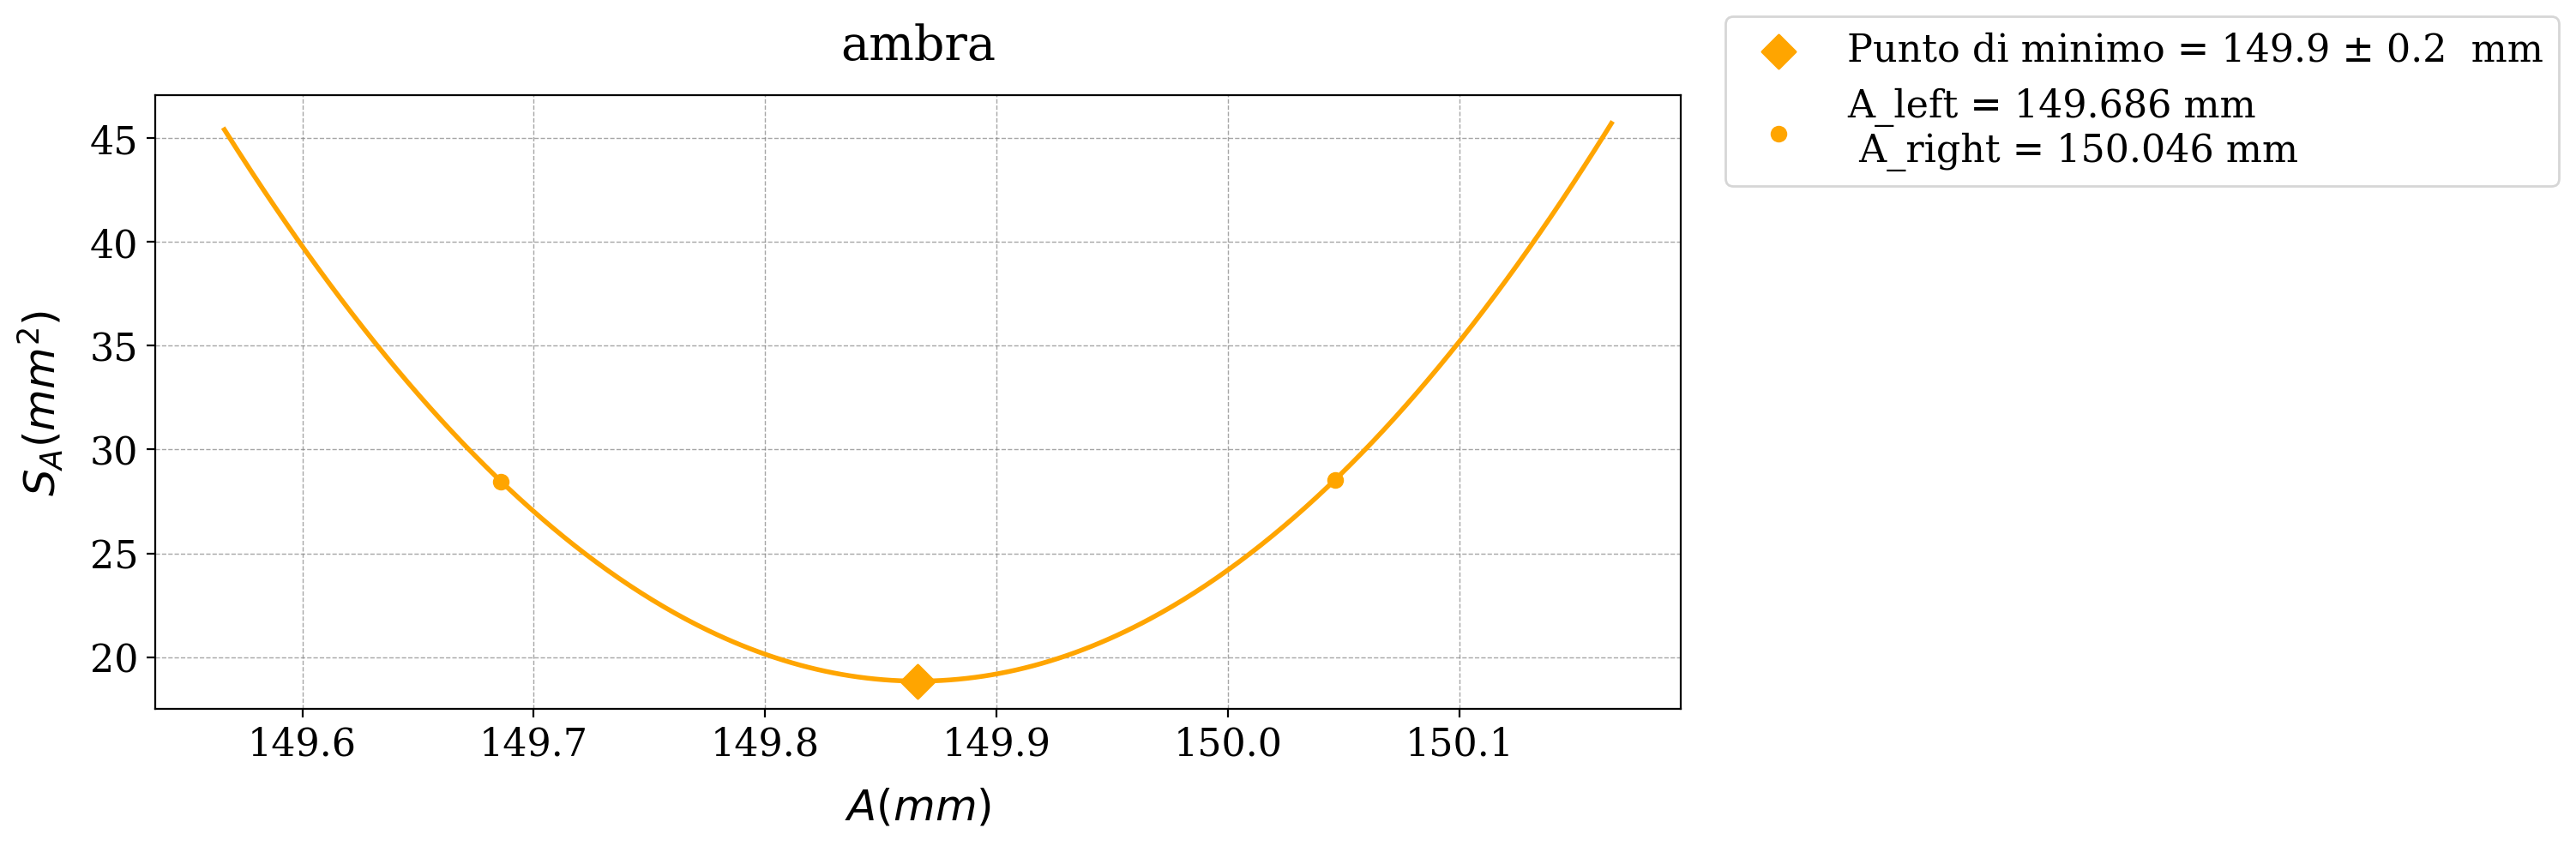

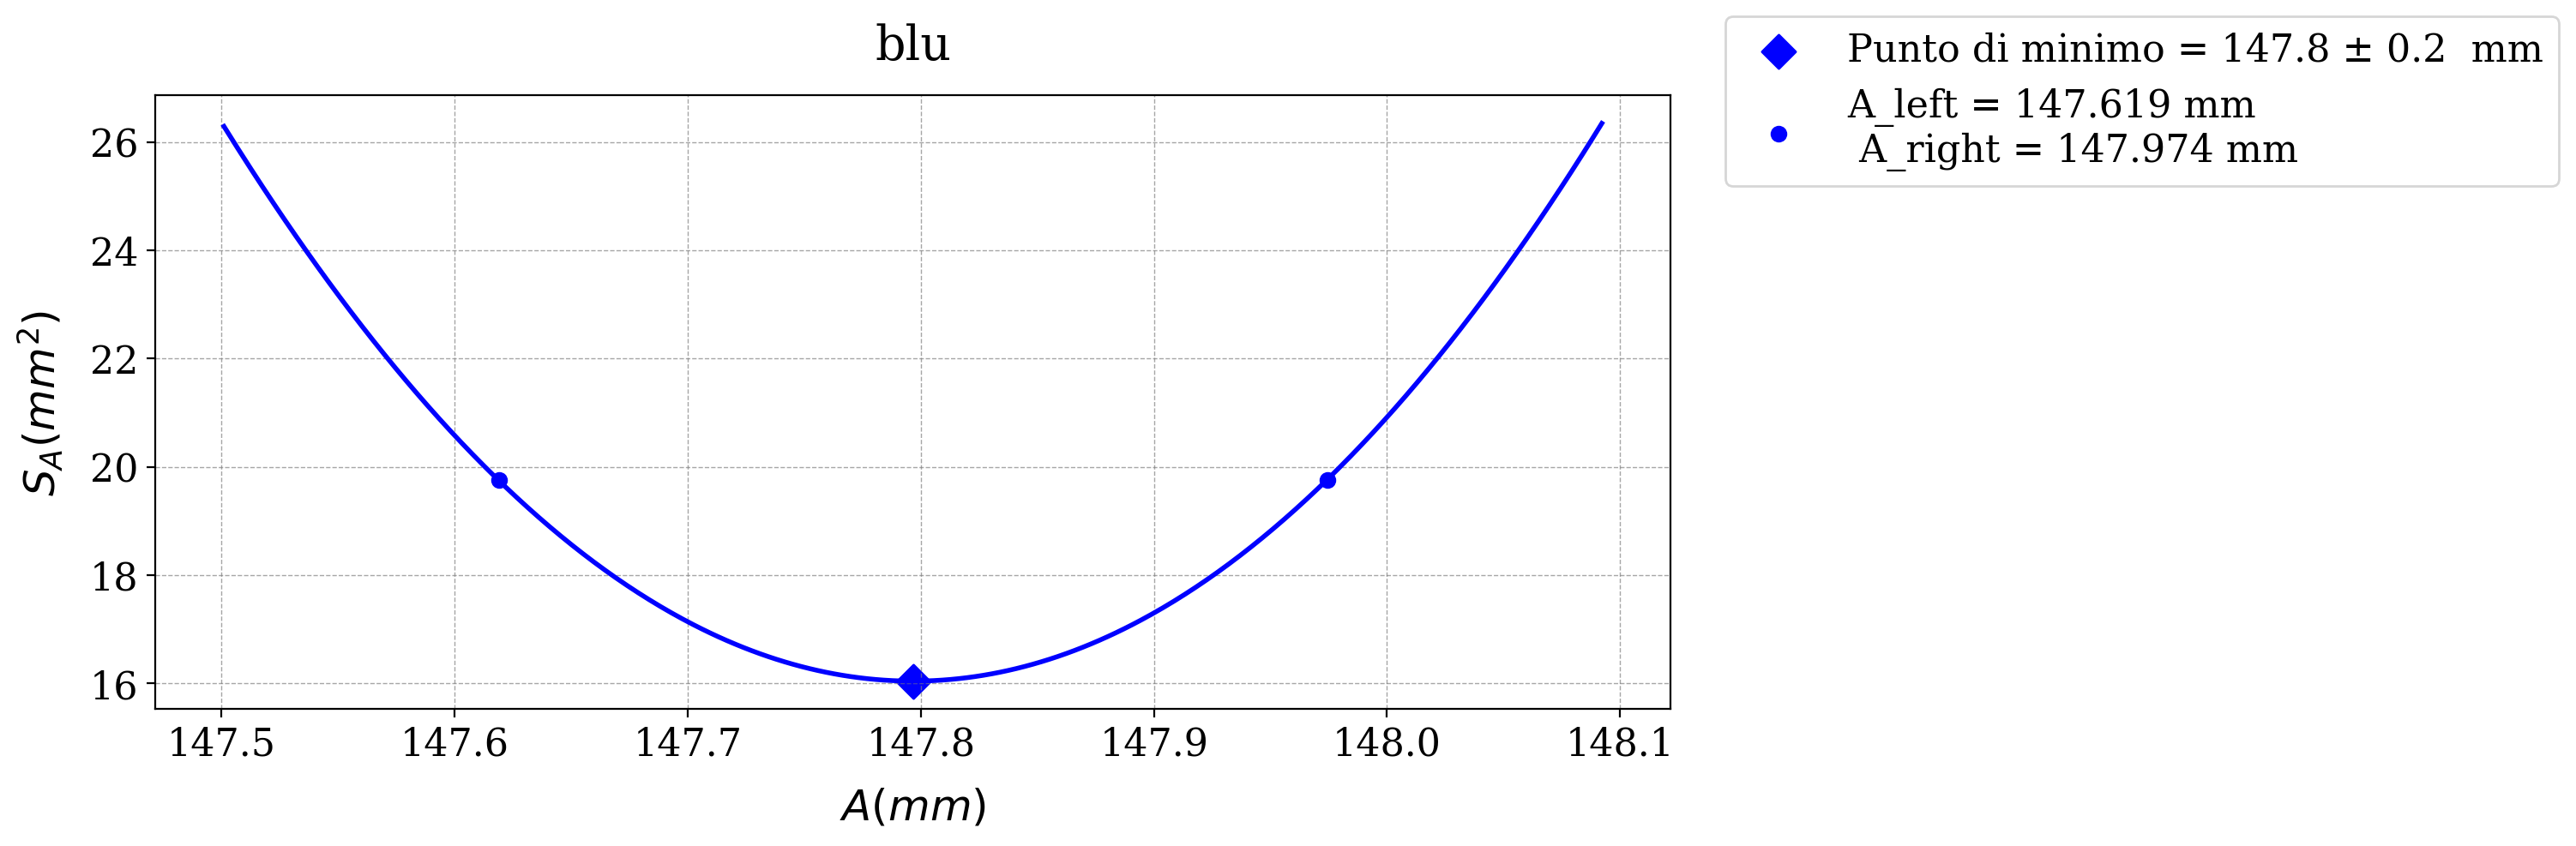

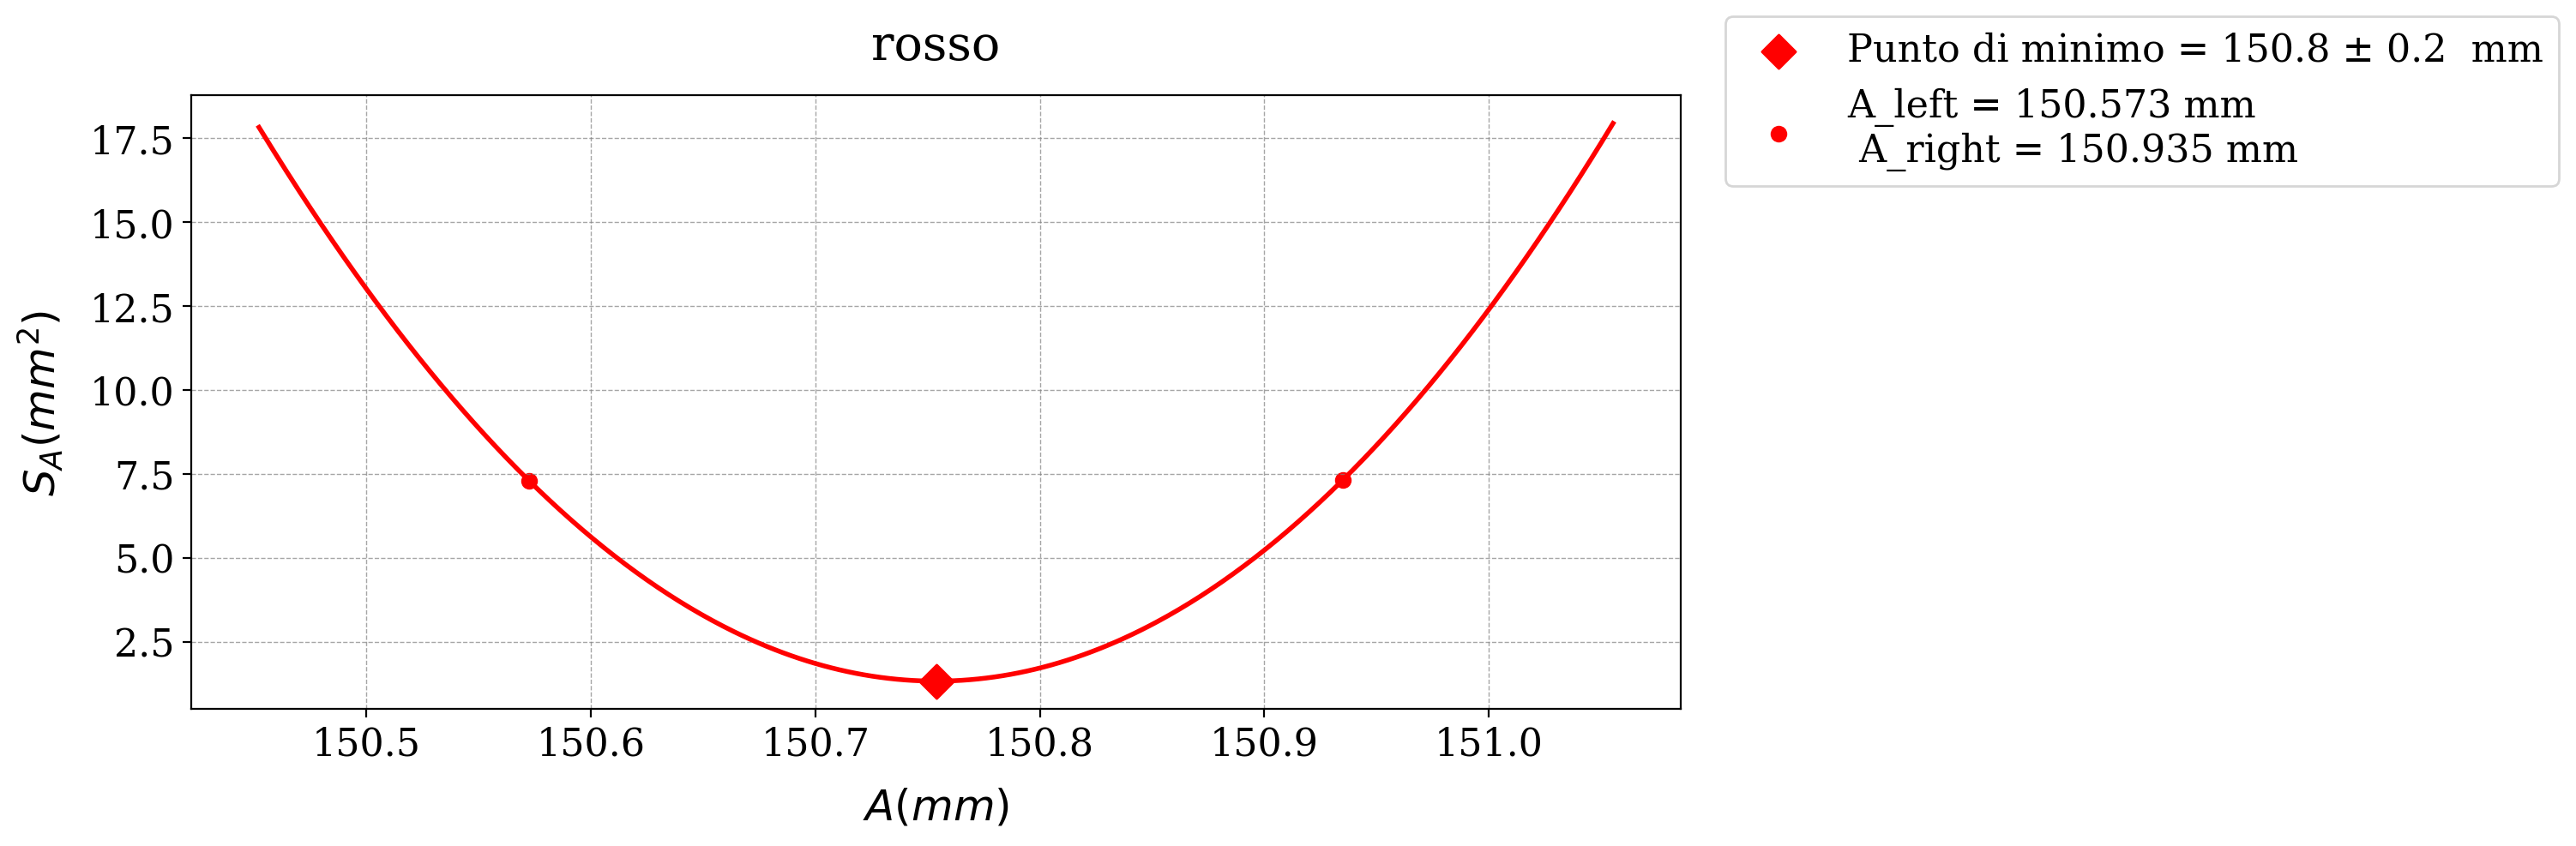

In [289]:
percent_meno = 0.2
percent_piu = 0.2

for i, (colore, distanza) in enumerate(distanze.items()):
    fig,ax = plt.subplots(1, 1, figsize=(10,5))
    gf.parametri_grafico(ax, colore, "$A (mm)$", r"$S_A (mm^2)$")
    if i == 0 : color = "orange"
    elif i == 1 : color = "blue"
    elif i == 2 : color = "red"
    p = distanza["p"]
    q = distanza["q"]
    stima = focali1_comp[colore]["minimi_quadrati"]
    def sommatoria(p,q,A):
        return np.sum((q - (A * p) / (p - A))**2)
    legenda1 = f"Punto di minimo = {gf.formatta_errore(stima[0],stima[1],txt=True)} mm"

    # Linea continua
    A = np.linspace(f.percento(stima[0],percent_meno,"-"), f.percento(stima[0],percent_piu,"+"), 500)
    SA = [sommatoria(p[0],q[0],x_val) for x_val in A]
    ax.plot(A, SA, color=color)
    ax.scatter([stima[0]],[sommatoria(p[0],q[0],stima[0])],color=color,marker="D",s=100,label=legenda1)

    # Semidispersione
    A_semidisp = focali1_anal[colore]["A"]
    SA_semidisp = [sommatoria(p[0],q[0],A_valore) for A_valore in A_semidisp]
    legenda2 = r"A_left = " + f"{A_semidisp[0]:.3f} mm" + "\n" + r" A_right = " f"{A_semidisp[1]:.3f} mm"
    ax.scatter(A_semidisp,SA_semidisp,color=color,label=legenda2)

    # Punti
    A = np.linspace(f.percento(stima[0],percent_meno,"-"), f.percento(stima[0],percent_piu,"+"), 10)
    SA = [sommatoria(p[0],q[0],x_val) for x_val in A]
    #ax.scatter(A, SA, color=color)
    gf.salva_grafico(fig, f"./Grafici/coniugati_minimi_quadrati_{colore}.pdf")

In [290]:
gf.display_dizionario(focali1_comp)

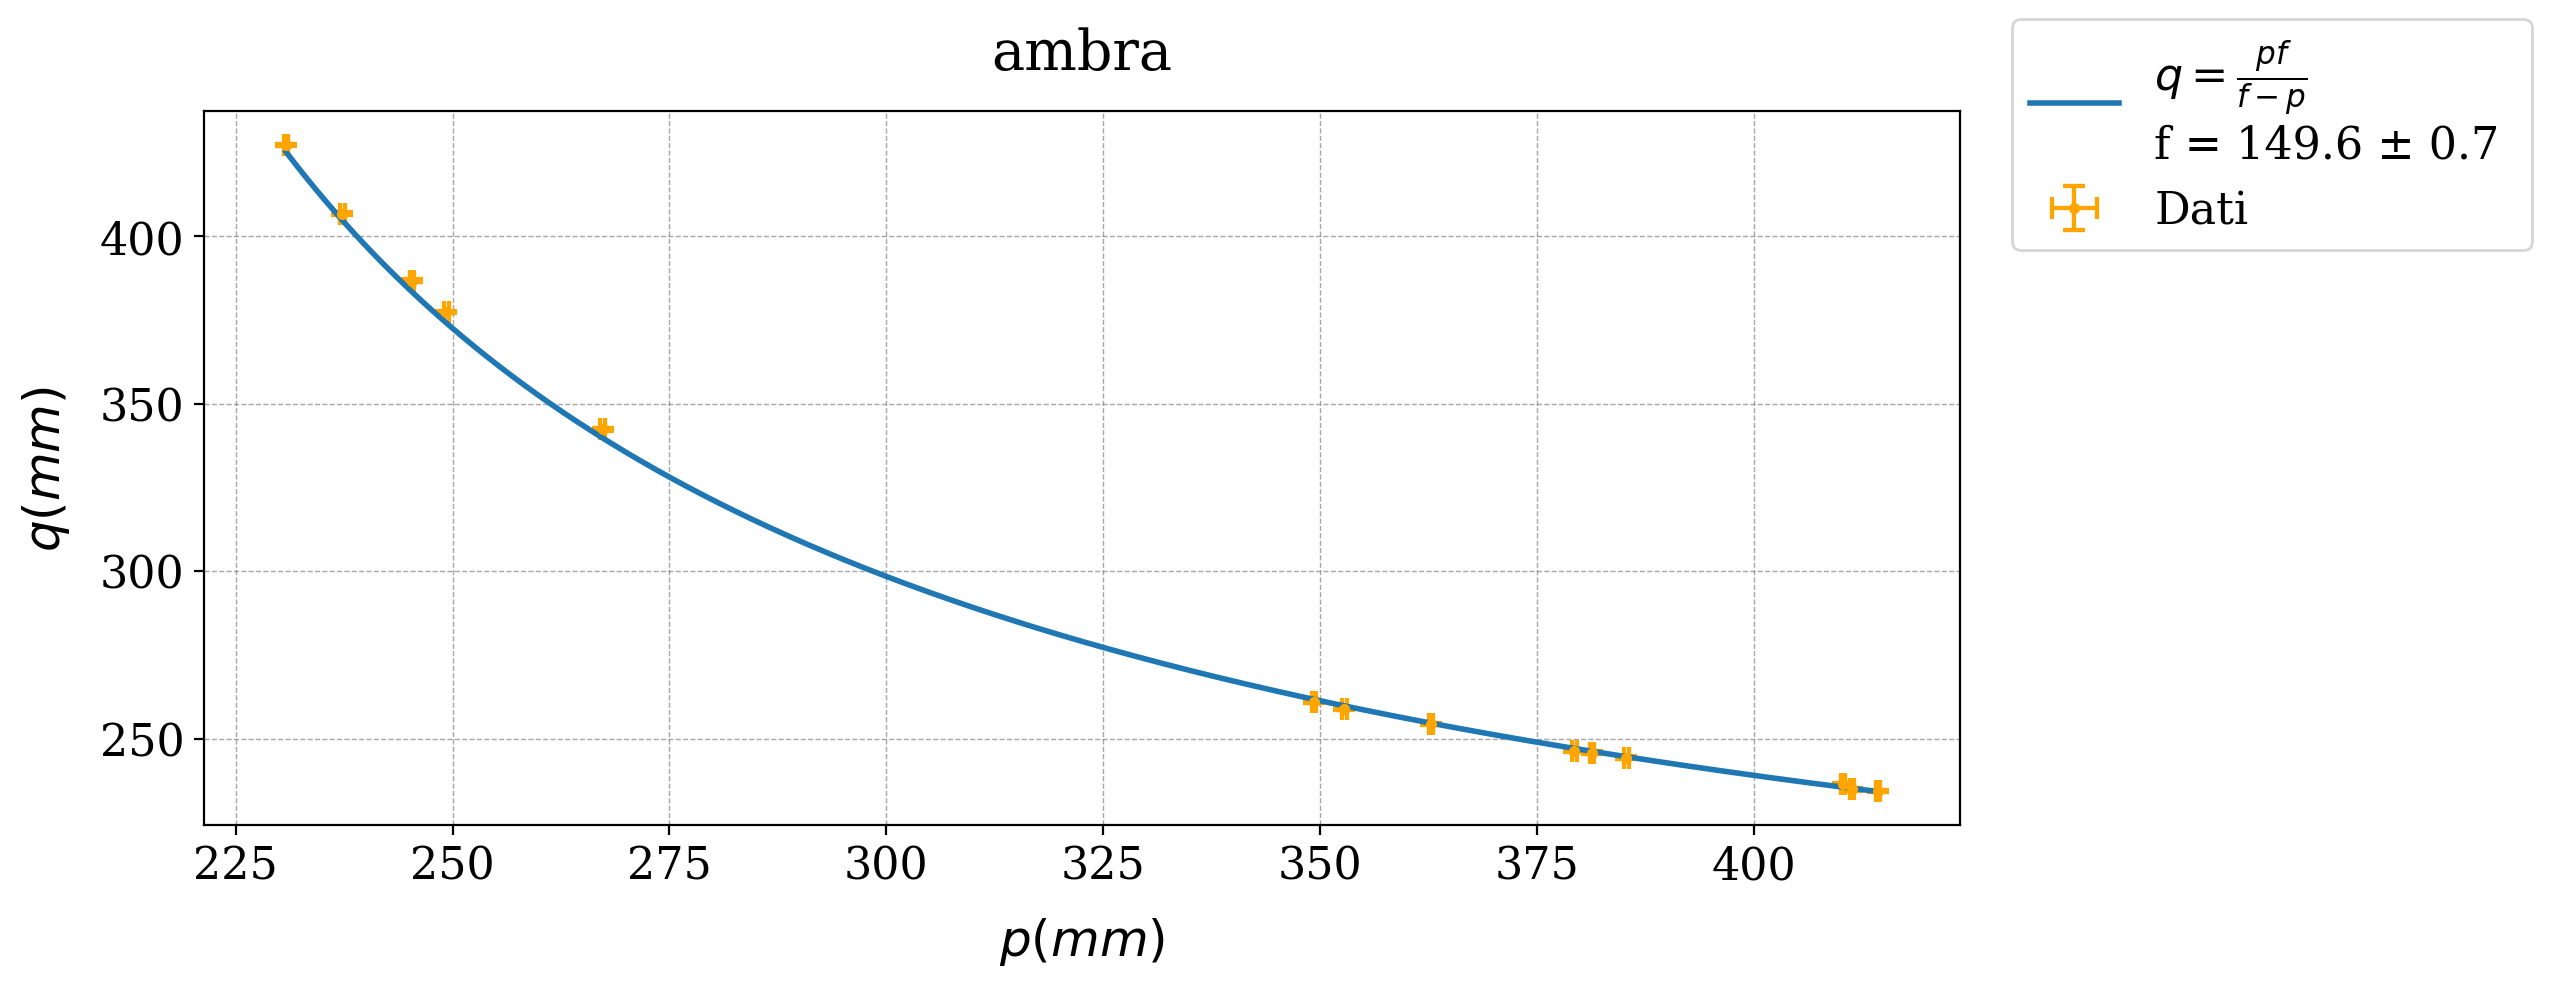

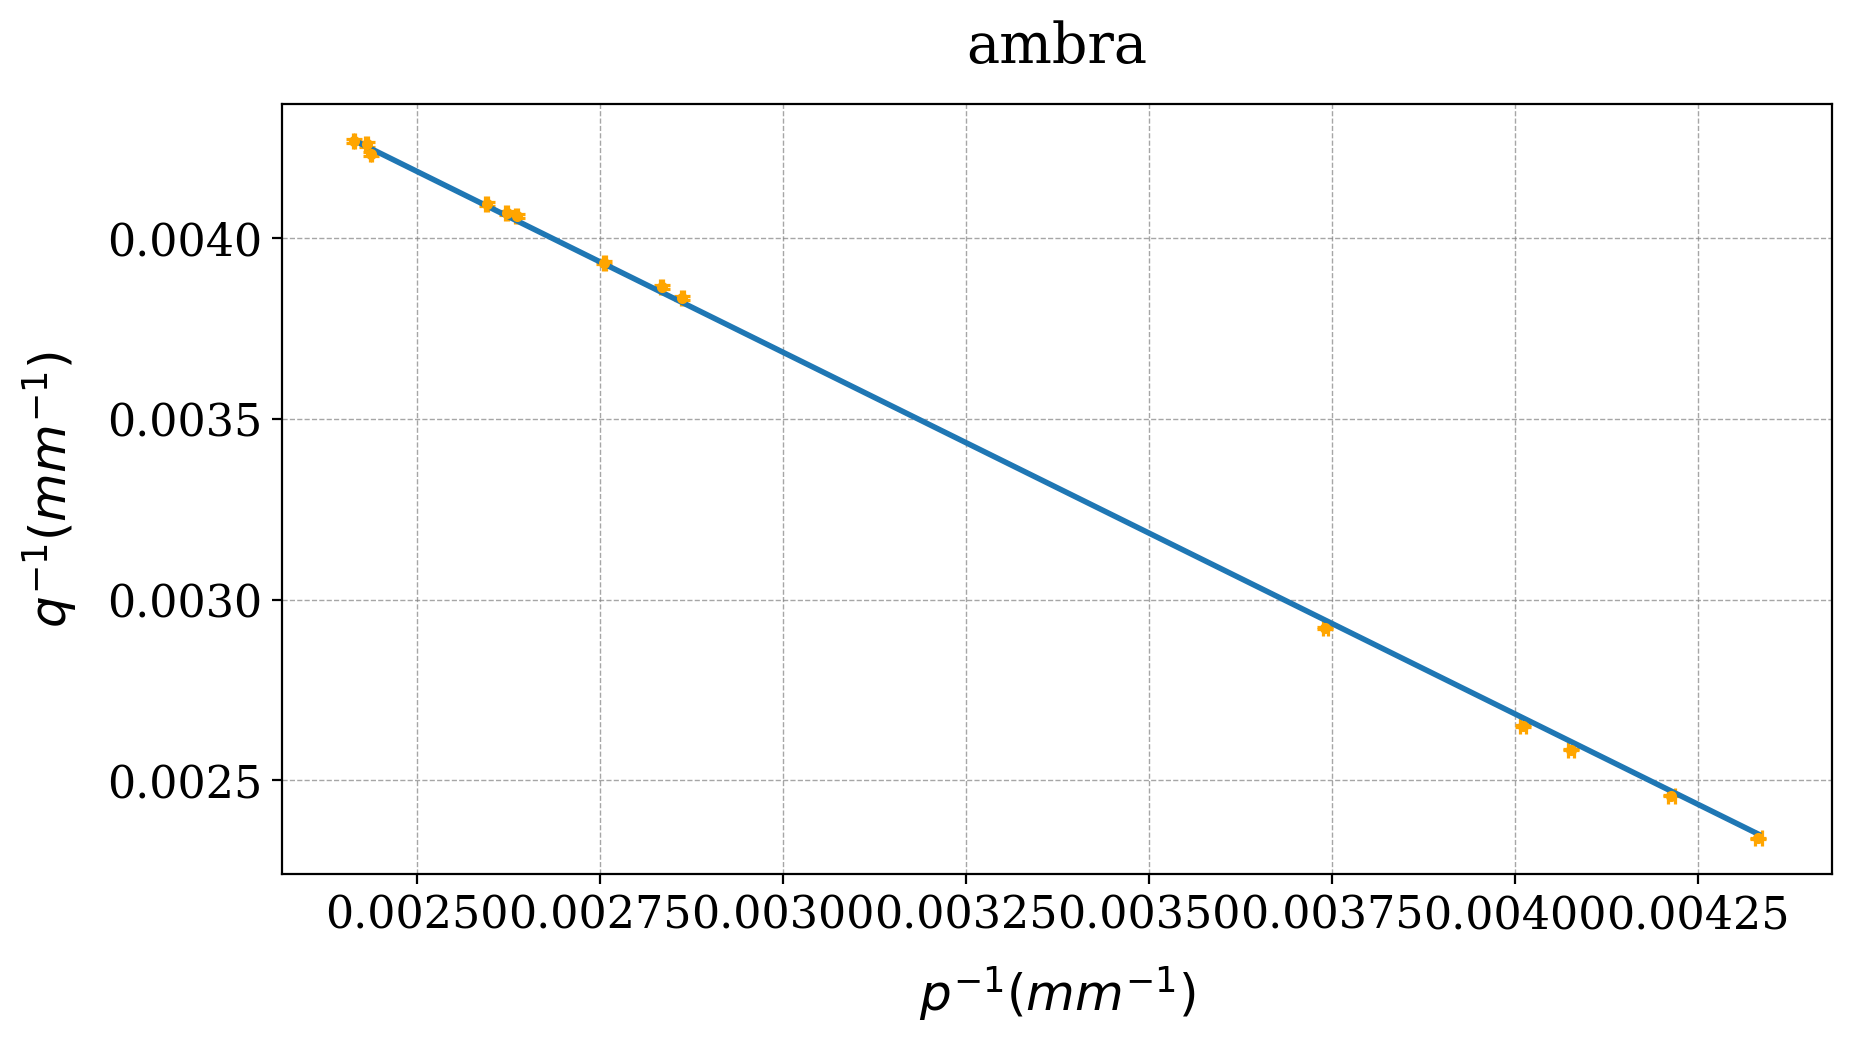

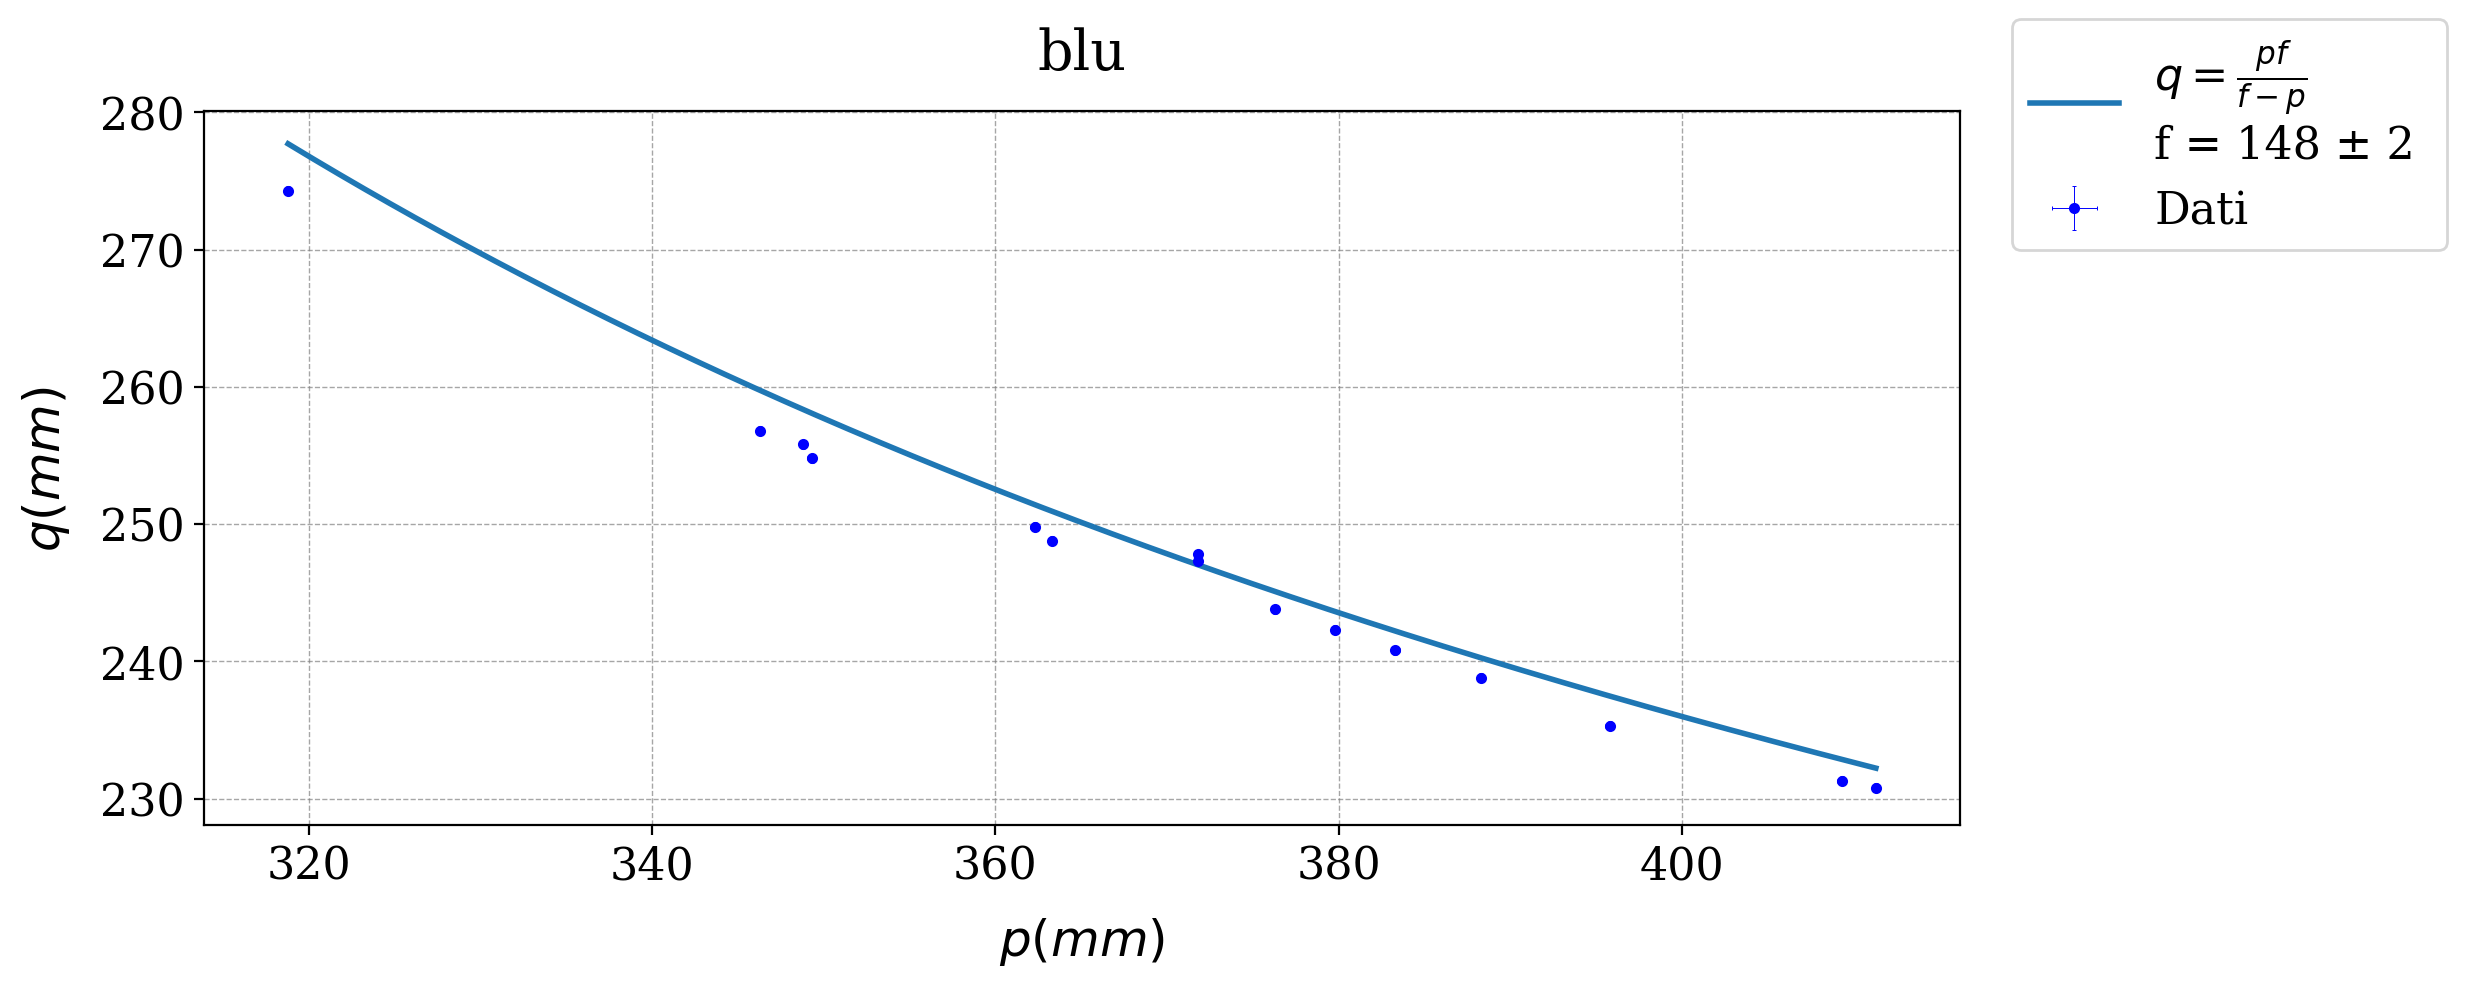

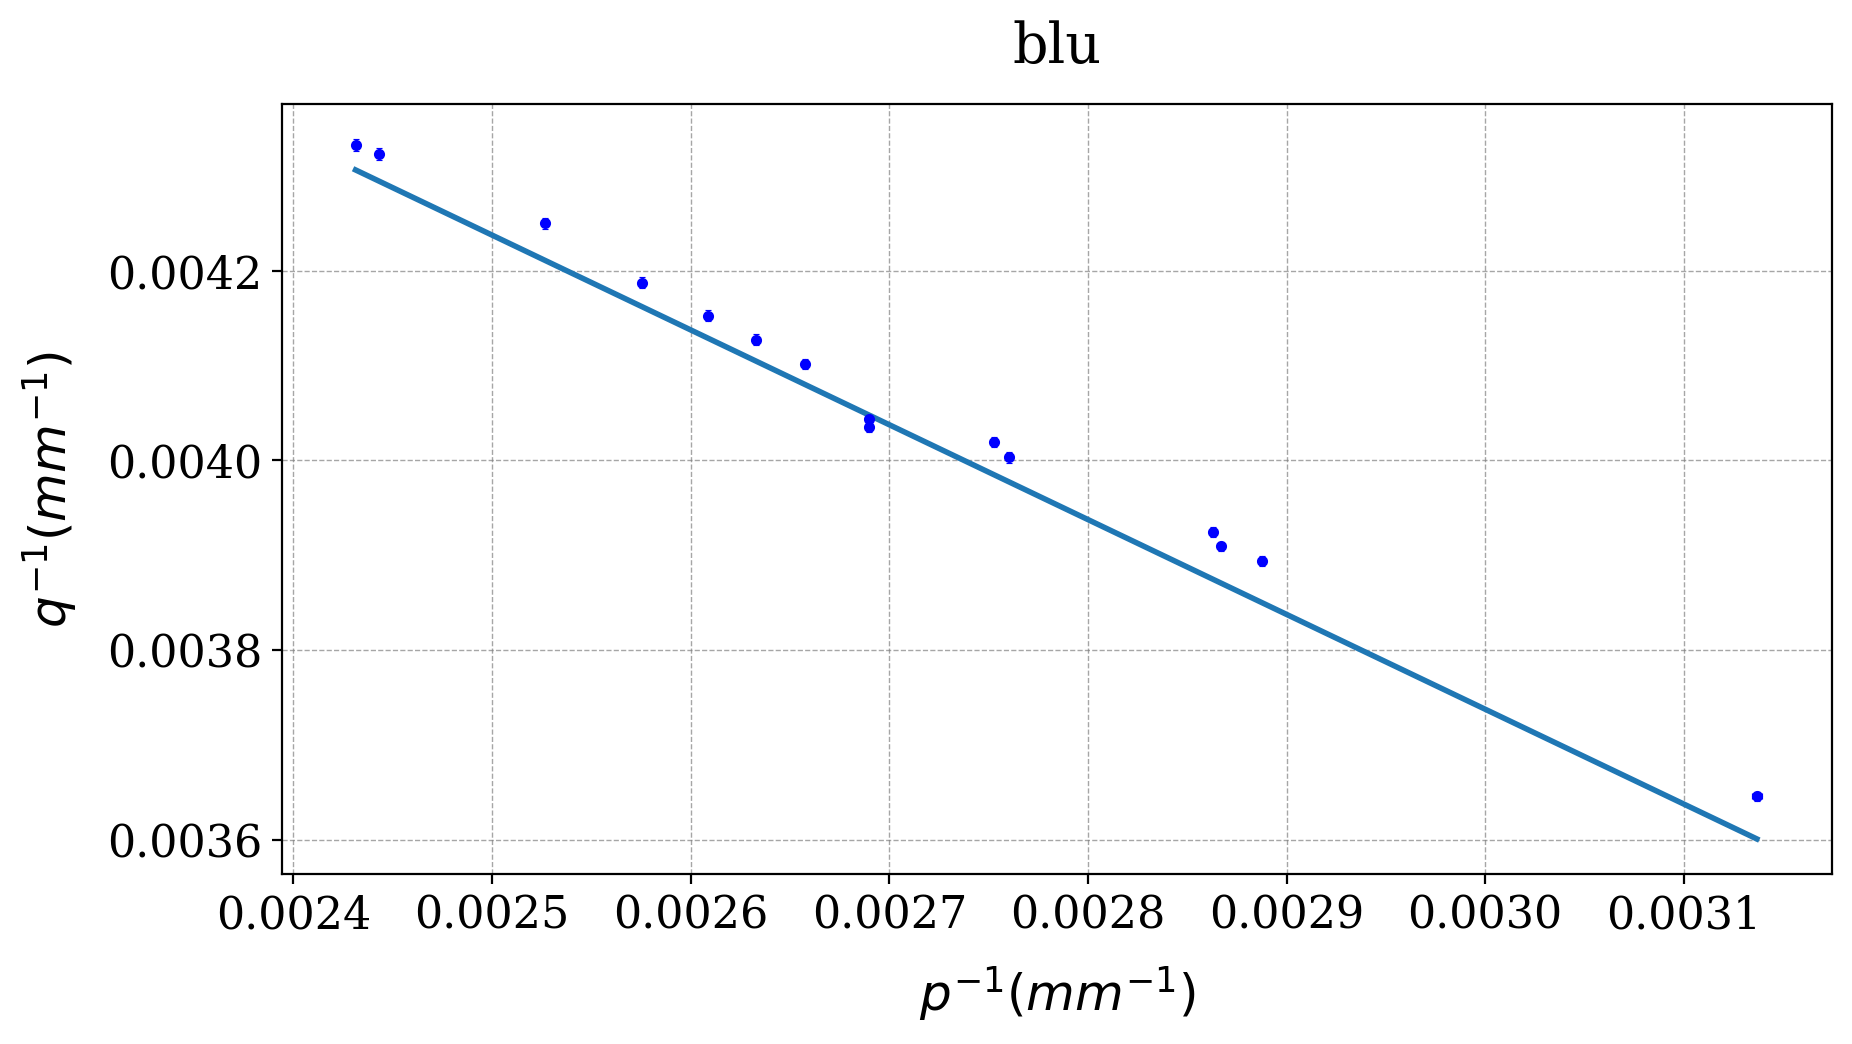

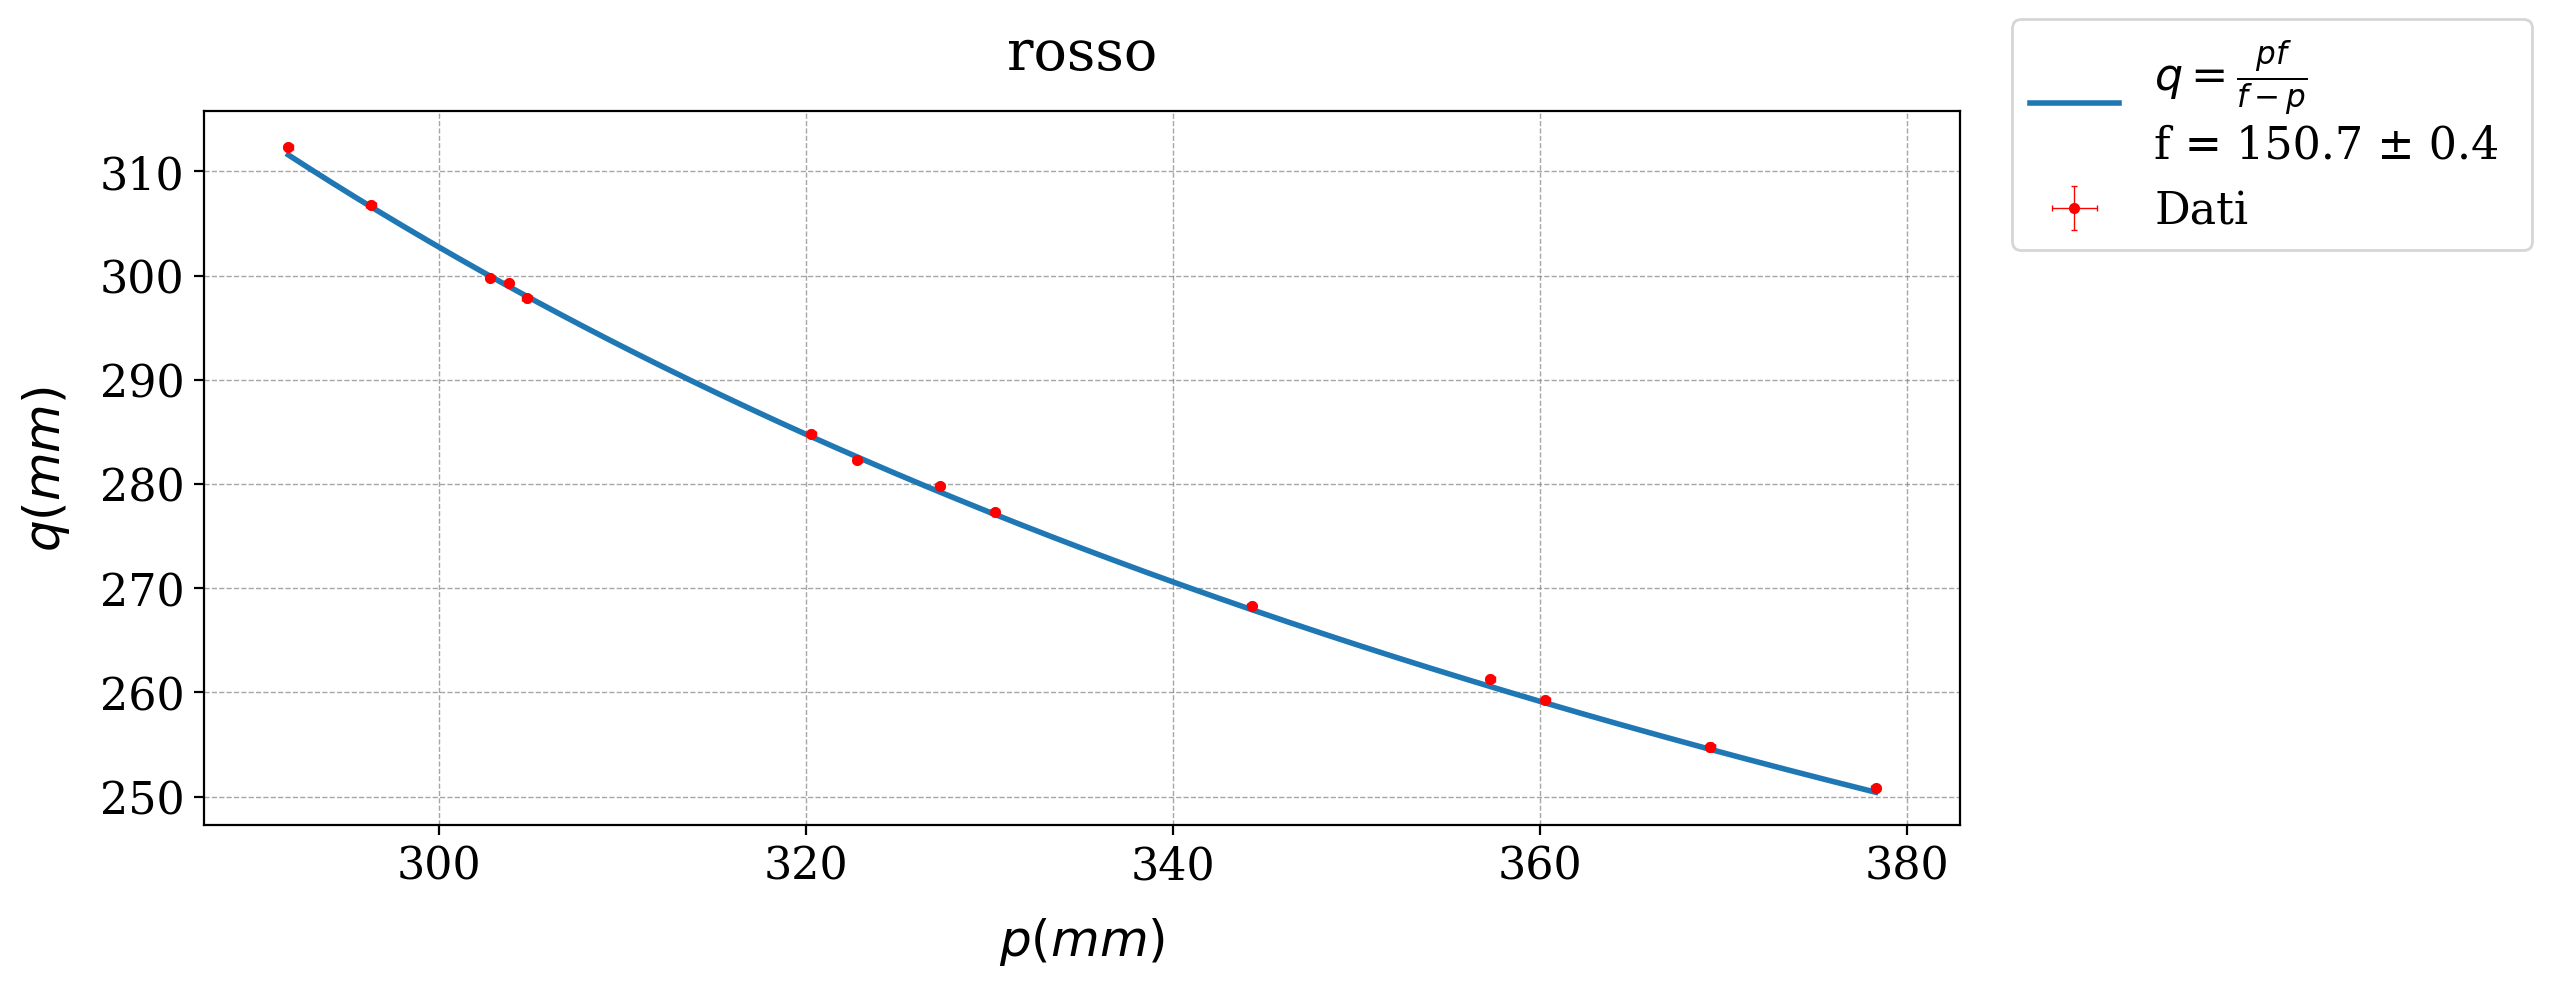

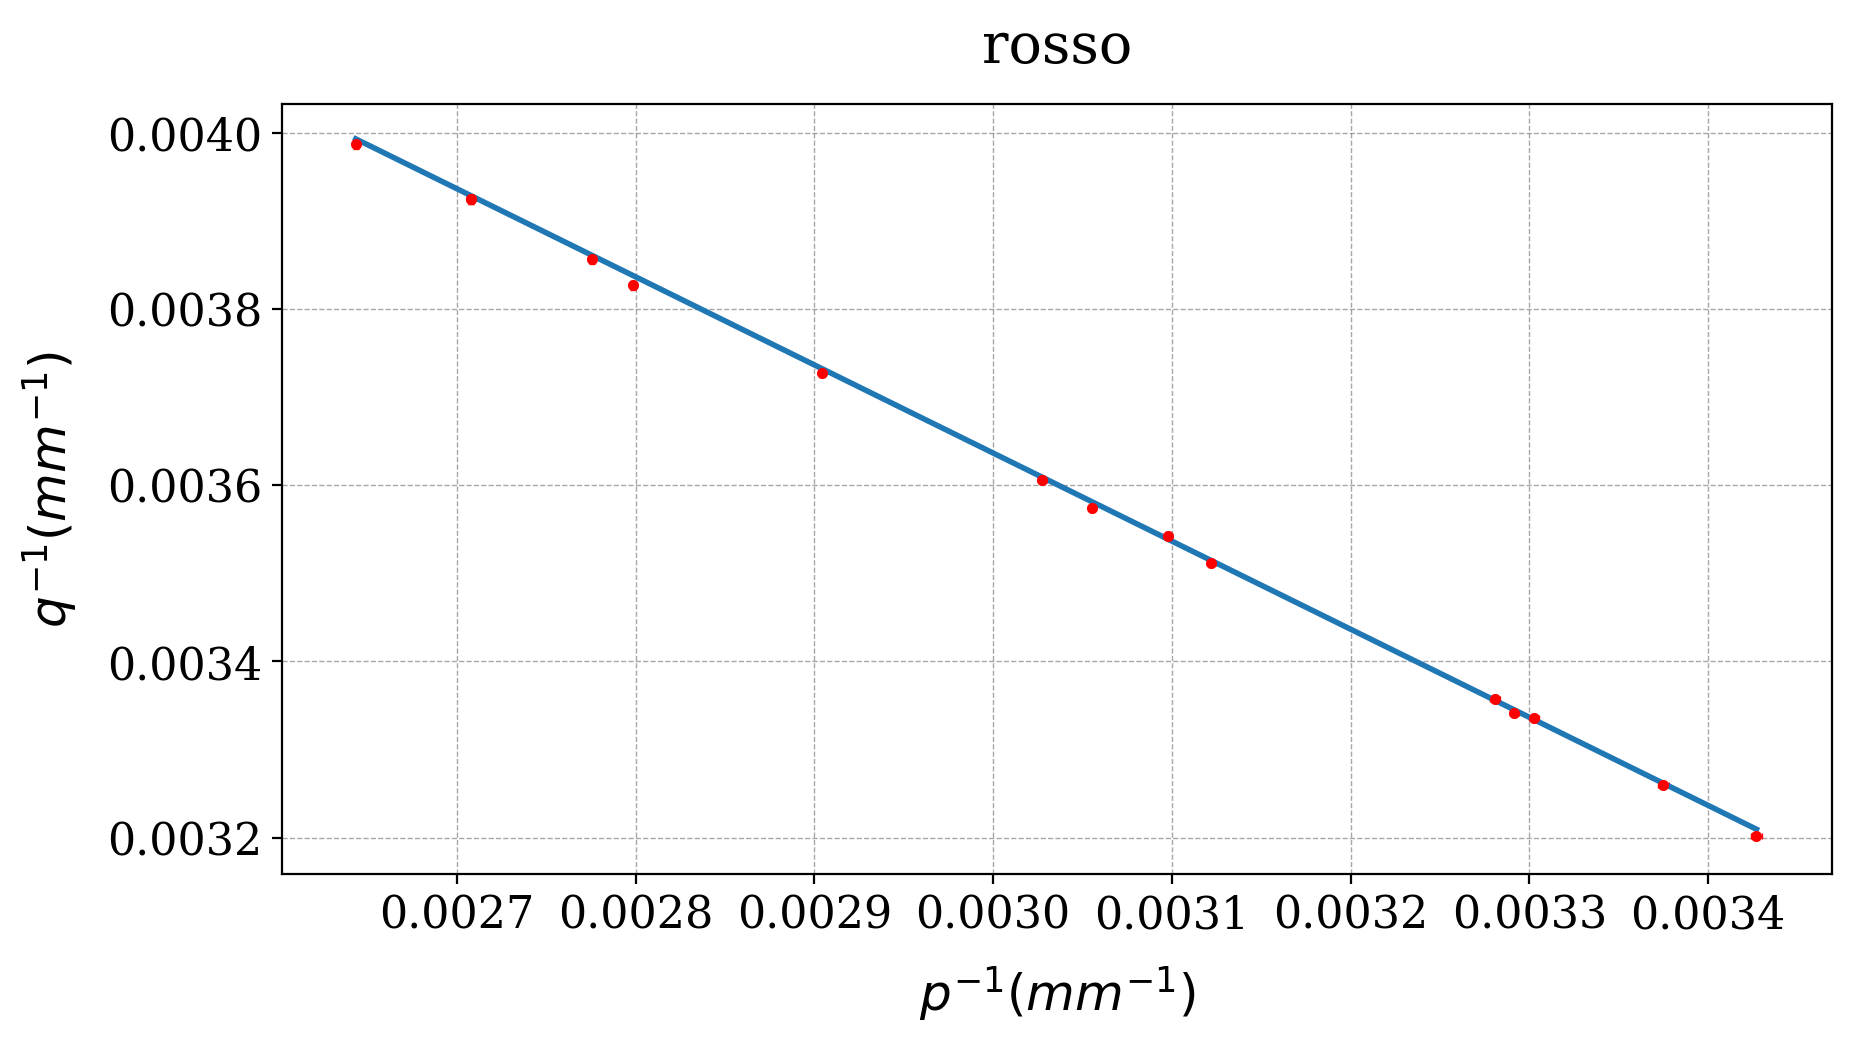

In [291]:
scala = 0.4
for i, (colore, distanza) in enumerate(distanze.items()):
    fig1,ax1 = plt.subplots(1, 1, figsize=(10,5))
    fig2,ax2 = plt.subplots(1, 1, figsize=(10,5))
    if i == 0 : color = "orange"
    elif i == 1 : color = "blue"
    elif i == 2 : color = "red"
    focale = focali1_comp[colore]["lineare"]
    p = distanza["p"]
    q = distanza["q"]

    legenda1 = r"$q = \frac{p f}{f - p}$" + f"\nf = {gf.formatta_errore(focale[0],focale[1],txt=True)}"
    #[a,b] = [focali1_anal[colore]["fp"]["a"],focali1_anal[colore]["fp"]["b"]]
    #legenda2 = f"y = a + bx\na = {gf.formatta_errore(a[0],b[1],txt=True)} e b = {gf.formatta_errore(b[0],b[1],txt=True)}"
    legenda2 = r"$\frac{1}{q} = \frac{1}{f} - \frac{1}{p}$" + f"\nf = {gf.formatta_errore(focale[0],focale[1],txt=True)}"

    # Grafico 1, non linearizzato
    ax = ax1
    gf.parametri_grafico(ax, colore, "$p(mm)$", "$q(mm)$")
    ax.errorbar(p[0], q[0], xerr = p[1], yerr = q[1], label="Dati", color=color, fmt=".", **gf.scaled_error_params(q[0], scale_factor=0.4))
    x = np.linspace(np.min(p[0]), np.max(p[0]), 500)
    y = 1 / (1/focale[0] - 1/x)
    ax.plot(x, y, label=legenda1)

    # Grafico 2, linearizzato
    ax = ax2
    ax.errorbar(1/p[0], 1/q[0], xerr = p[1] / (p[0]**2) , yerr = q[1] / (q[0]**2), label="Dati", color=color, fmt=".", **gf.scaled_error_params(1/q[0], scale_factor=0.3*100000))
    gf.parametri_grafico(ax, colore, "$p^{-1}(mm^{-1})$", "$q^{-1}(mm^{-1})$")
    x = np.linspace(np.min(1/p[0]), np.max(1/p[0]), 500)
    y = 1/focale[0] - x
    ax.plot(x, y, label=legenda2)

    gf.salva_grafico(fig1, f"./Grafici/coniugati_non_linearizzati_{colore}.pdf")
    gf.salva_grafico(fig2, f"./Grafici/coniugati_linearizzati_{colore}.pdf")